In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
from scipy.cluster.hierarchy import fcluster

In [2]:
df = pd.read_pickle('pkl/GI_cluster50_labelled_all_mar28.pkl')

In [3]:
df 

label      X  \
paad TCGA-HZ-A9TJ-01Z-00-DX1.CB2953B6-9601-4300-BC89... 0         0   1792   
                                                        1         0   1792   
                                                        2        46   2048   
                                                        3        46   2048   
                                                        4        46   2048   
...                                                             ...    ...   
read TCGA-F5-6861-01Z-00-DX1.011B771B-F52E-412E-9352... 36609    13  94208   
                                                        36610    29  94208   
                                                        36611    29  94208   
                                                        36612    13  94208   
                                                        36613    13  94208   

                                                                   Y  
paad TCGA-HZ-A9TJ-01Z-00-DX1.CB2953B6-9601-4300-BC89... 0      11264  
                                                        1      11520  
                                                        2       9984  
                                                        3      10240  
                                                        4      10496  
...                                                              ...  
read TCGA-F5-6861-01Z-00-DX1.011B771B-F52E-412E-9352... 36609  20736  
                                                        36610  20992  
                                                        36611  21248  
                                                        36612  21504  
                                                        36613  21760  

[85078334 rows x 3 columns]

In [4]:
summary_df = pd.read_pickle('pkl/cluster_50_pairwise_summary_04_06_26.pkl')

In [5]:
summary_df 

,cancer_type,cluster 1,cluster 2,contact count,total cluster 1,total_c1_interactions,frequency
0,coad,0,1,77,239810,1871860,0.000041
1,coad,0,2,3480,612543,4738758,0.000734
2,coad,0,3,58,48398,370757,0.000156
3,coad,0,4,16,1003,6726,0.002379
4,coad,0,5,554,282791,2190947,0.000253
...,...,...,...,...,...,...,...
5814,stad,46,48,23826,326760,2409259,0.009889
5815,stad,46,49,27181,452970,3323591,0.008178
5816,stad,47,48,12384,85161,647334,0.019131
5817,stad,47,49,5744,143759,1106262,0.005192


In [7]:
cancer_types = ['coad', 'esca', 'paad', 'read', 'stad']
num_clusters = 50 

In [8]:
from itertools import combinations
all_pairs = []
for ct in cancer_types:
    for c1, c2 in combinations(range(num_clusters), 2):
        all_pairs.append({'cancer_type': ct, 'cluster 1': c1, 'cluster 2': c2})
all_pairs_df = pd.DataFrame(all_pairs)


In [9]:
all_pairs_df

,cancer_type,cluster 1,cluster 2
0,coad,0,1
1,coad,0,2
2,coad,0,3
3,coad,0,4
4,coad,0,5
...,...,...,...
6120,stad,46,48
6121,stad,46,49
6122,stad,47,48
6123,stad,47,49


In [10]:
# 1. Merge the dataframes
# 'left' ensures we keep all rows from all_pairs_df
merged_df = all_pairs_df.merge(
    summary_df[['cancer_type', 'cluster 1', 'cluster 2', 'frequency']], 
    on=['cancer_type', 'cluster 1', 'cluster 2'], 
    how='left'
)

# 2. Fill the missing frequencies with 0
merged_df['frequency'] = merged_df['frequency'].fillna(0)

In [11]:
merged_df

,cancer_type,cluster 1,cluster 2,frequency
0,coad,0,1,0.000041
1,coad,0,2,0.000734
2,coad,0,3,0.000156
3,coad,0,4,0.002379
4,coad,0,5,0.000253
...,...,...,...,...
6120,stad,46,48,0.009889
6121,stad,46,49,0.008178
6122,stad,47,48,0.019131
6123,stad,47,49,0.005192


In [10]:
# 1. Define the noisy clusters
noisy = [0, 3, 4, 7, 21, 27, 34, 39, 45, 46]

# 2. Filter out noisy clusters from BOTH cluster columns
# This ensures we only look at high-quality biological interactions
clean_summary = summary_df[
    (~summary_df['cluster 1'].isin(noisy)) & 
    (~summary_df['cluster 2'].isin(noisy))
].copy()

# 3. Group by the pair and calculate Mean and Std of the frequency
# We group by the clusters to see how the frequency behaves across the 5 cancer types
stats_df = clean_summary.groupby(['cluster 1', 'cluster 2'])['frequency'].agg(['mean', 'std','max', 'min']).reset_index()

# 4. Calculate the Coefficient of Variation (CV)
# CV = Standard Deviation / Mean
# We add a tiny epsilon (1e-5) to avoid division by zero
stats_df['cv'] = stats_df['std'] / (stats_df['mean'] + 1e-10)
stats_df['max_min_ratio'] = stats_df['max'] / (stats_df['min'] + 1e-10)

# 5. Sort to find the most conserved pairs (Lowest CV first)
conserved_pairs = stats_df.sort_values('cv', ascending=True)

# Display the top 10 most conserved interactions
display(conserved_pairs.head(10))

,cluster 1,cluster 2,mean,std,max,min,cv,max_min_ratio
270,11,32,0.000015,8.020239e-07,0.000016,0.000015,0.052225,1.076682
706,33,40,0.078928,6.195358e-03,0.086877,0.071742,0.078494,1.210967
605,25,44,0.000301,2.461649e-05,0.000327,0.000263,0.081867,1.242047
61,2,30,0.011421,1.827276e-03,0.013317,0.009194,0.159992,1.448423
614,26,33,0.002168,3.535059e-04,0.002560,0.001710,0.163041,1.497072
644,29,30,0.000393,7.056553e-05,0.000470,0.000304,0.179422,1.544886
295,12,25,0.000434,7.933399e-05,0.000553,0.000355,0.182688,1.559419
280,11,44,0.007739,1.457620e-03,0.009262,0.005400,0.188356,1.715149
75,2,48,0.027487,5.260859e-03,0.033858,0.021500,0.191397,1.574811
623,26,44,0.019468,3.759621e-03,0.023254,0.013735,0.193119,1.693040


In [20]:
least_conserved = stats_df.sort_values('cv', ascending=False) 
display(least_conserved.head(10))

,cluster 1,cluster 2,mean,std,max,min,cv,max_min_ratio
196,9,22,0.018613,0.040417,0.090909,0.000183,2.171495,497.205007
510,20,29,0.025972,0.055362,0.125000,0.000112,2.131588,1116.316230
245,10,41,0.042803,0.088695,0.201442,0.000717,2.072149,280.894807
241,10,36,0.016930,0.035010,0.079545,0.000609,2.067933,130.684787
601,25,40,0.003628,0.007448,0.016949,0.000125,2.053231,135.587462
475,18,43,0.026857,0.054902,0.125000,0.000261,2.044224,479.697184
260,11,20,0.005625,0.011459,0.026115,0.000082,2.037030,319.811516
619,26,40,0.004528,0.009107,0.020811,0.000156,2.010994,133.056572
195,9,20,0.007299,0.014649,0.033489,0.000130,2.006849,257.285227
224,10,16,0.012413,0.024861,0.056848,0.000421,2.002849,135.156694


In [15]:
conserved_pairs_2 = stats_df.sort_values('max_min_ratio', ascending=True) 
display(conserved_pairs_2.head(10))

,cluster 1,cluster 2,mean,std,max,min,cv,max_min_ratio
238,10,32,0.000028,NaN,0.000028,0.000028,NaN,0.999996
348,14,18,0.000215,NaN,0.000215,0.000215,NaN,1.000000
270,11,32,0.000015,8.020239e-07,0.000016,0.000015,0.052225,1.076682
706,33,40,0.078928,6.195358e-03,0.086877,0.071742,0.078494,1.210967
605,25,44,0.000301,2.461649e-05,0.000327,0.000263,0.081867,1.242047
61,2,30,0.011421,1.827276e-03,0.013317,0.009194,0.159992,1.448423
614,26,33,0.002168,3.535059e-04,0.002560,0.001710,0.163041,1.497072
644,29,30,0.000393,7.056553e-05,0.000470,0.000304,0.179422,1.544886
295,12,25,0.000434,7.933399e-05,0.000553,0.000355,0.182688,1.559419
75,2,48,0.027487,5.260859e-03,0.033858,0.021500,0.191397,1.574811


In [21]:
least_conserved_2 = stats_df.sort_values('max_min_ratio', ascending=False) 
display(least_conserved_2.head(10))

,cluster 1,cluster 2,mean,std,max,min,cv,max_min_ratio
230,10,23,0.166899,0.288474,0.500000,0.000046,1.728434,10952.976006
373,14,49,0.063988,0.096435,0.230769,0.000023,1.507068,9877.140417
362,14,35,0.333354,0.288639,0.500000,0.000063,0.865862,7949.130219
357,14,29,0.118644,0.139247,0.320000,0.000044,1.173655,7198.005627
355,14,26,0.067425,0.069385,0.155556,0.000028,1.029073,5656.312766
364,14,37,0.166689,0.190912,0.375000,0.000067,1.145316,5619.291580
366,14,40,0.038278,0.043826,0.095652,0.000036,1.144949,2689.741815
361,14,33,0.045828,0.059430,0.125000,0.000088,1.296790,1426.956704
352,14,23,0.099352,0.114334,0.200000,0.000143,1.150795,1398.231676
246,10,42,0.003494,0.006554,0.015197,0.000011,1.875849,1331.610096


In [23]:
top_20_mean_df['mean'].min() 

np.float64(0.028886736568339143)

In [24]:
top_20_mean_df['mean'].max() 

np.float64(0.33335429995447247)

In [32]:
mean_threshold = stats_df['mean'].quantile(0.8)
top_20_mean_df = stats_df[stats_df['mean'] >= 0.01].copy()
top_20_mean_df = top_20_mean_df.sort_values('cv', ascending=True)
top_20_mean_df.head(10)

,cluster 1,cluster 2,mean,std,max,min,cv,max_min_ratio
706,33,40,0.078928,0.006195,0.086877,0.071742,0.078494,1.210967
61,2,30,0.011421,0.001827,0.013317,0.009194,0.159992,1.448423
75,2,48,0.027487,0.005261,0.033858,0.021500,0.191397,1.574811
623,26,44,0.019468,0.003760,0.023254,0.013735,0.193119,1.693040
123,6,17,0.020545,0.004002,0.026039,0.016083,0.194808,1.618984
344,13,49,0.015719,0.003110,0.017727,0.010355,0.197824,1.711854
290,12,19,0.021790,0.004704,0.025449,0.013943,0.215897,1.825249
713,33,49,0.033500,0.007278,0.043855,0.026816,0.217262,1.635387
148,6,48,0.026610,0.005799,0.036279,0.021109,0.217938,1.718674
643,28,49,0.053367,0.011947,0.069886,0.038169,0.223856,1.830990


In [33]:
top_20_mean_df_2 = top_20_mean_df.sort_values('max_min_ratio', ascending=True)
top_20_mean_df_2.head(10)

,cluster 1,cluster 2,mean,std,max,min,cv,max_min_ratio
706,33,40,0.078928,0.006195,0.086877,0.071742,0.078494,1.210967
61,2,30,0.011421,0.001827,0.013317,0.009194,0.159992,1.448423
75,2,48,0.027487,0.005261,0.033858,0.021500,0.191397,1.574811
123,6,17,0.020545,0.004002,0.026039,0.016083,0.194808,1.618984
713,33,49,0.033500,0.007278,0.043855,0.026816,0.217262,1.635387
623,26,44,0.019468,0.003760,0.023254,0.013735,0.193119,1.693040
134,6,30,0.093772,0.021577,0.125257,0.073771,0.230104,1.697919
344,13,49,0.015719,0.003110,0.017727,0.010355,0.197824,1.711854
148,6,48,0.026610,0.005799,0.036279,0.021109,0.217938,1.718674
432,17,22,0.075718,0.017405,0.093835,0.054408,0.229860,1.724634


In [34]:
varied_df = top_20_mean_df.sort_values('cv', ascending = False) 
varied_df.head(10)

,cluster 1,cluster 2,mean,std,max,min,cv,max_min_ratio
196,9,22,0.018613,0.040417,0.090909,0.000183,2.171495,497.205007
510,20,29,0.025972,0.055362,0.125000,0.000112,2.131588,1116.316230
245,10,41,0.042803,0.088695,0.201442,0.000717,2.072149,280.894807
241,10,36,0.016930,0.035010,0.079545,0.000609,2.067933,130.684787
475,18,43,0.026857,0.054902,0.125000,0.000261,2.044224,479.697184
224,10,16,0.012413,0.024861,0.056848,0.000421,2.002849,135.156694
159,8,18,0.019798,0.038426,0.088467,0.000965,1.940925,91.677186
263,11,24,0.042300,0.081859,0.188702,0.003527,1.935172,53.500763
552,23,28,0.011475,0.021721,0.050266,0.000432,1.892982,116.436296
456,18,20,0.019898,0.037579,0.087012,0.001004,1.888607,86.649862


In [35]:
varied_df_2 = top_20_mean_df.sort_values('max_min_ratio', ascending = False) 
varied_df_2.head(10) 

,cluster 1,cluster 2,mean,std,max,min,cv,max_min_ratio
230,10,23,0.166899,0.288474,0.500000,0.000046,1.728434,10952.976006
373,14,49,0.063988,0.096435,0.230769,0.000023,1.507068,9877.140417
362,14,35,0.333354,0.288639,0.500000,0.000063,0.865862,7949.130219
357,14,29,0.118644,0.139247,0.320000,0.000044,1.173655,7198.005627
355,14,26,0.067425,0.069385,0.155556,0.000028,1.029073,5656.312766
364,14,37,0.166689,0.190912,0.375000,0.000067,1.145316,5619.291580
366,14,40,0.038278,0.043826,0.095652,0.000036,1.144949,2689.741815
361,14,33,0.045828,0.059430,0.125000,0.000088,1.296790,1426.956704
352,14,23,0.099352,0.114334,0.200000,0.000143,1.150795,1398.231676
510,20,29,0.025972,0.055362,0.125000,0.000112,2.131588,1116.316230


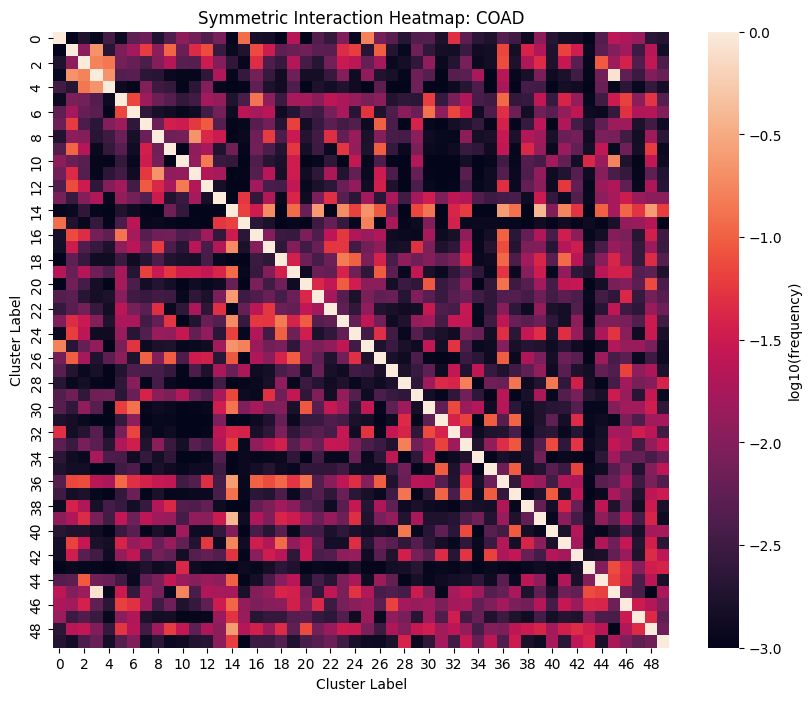

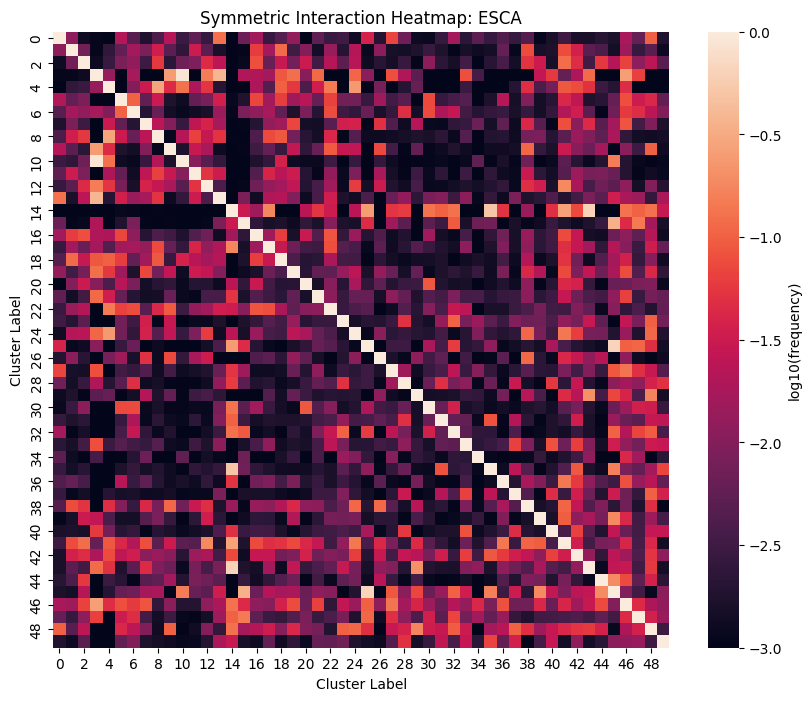

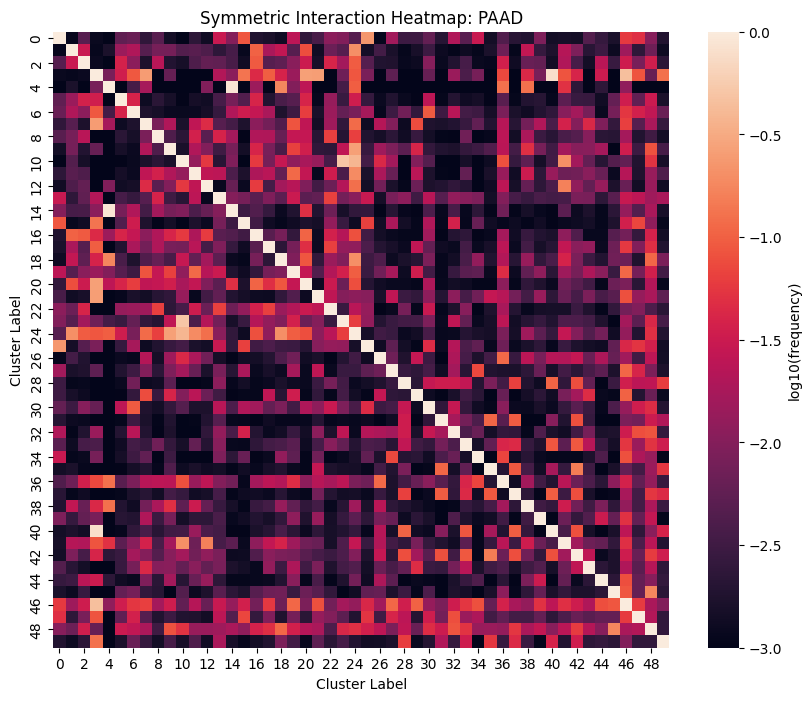

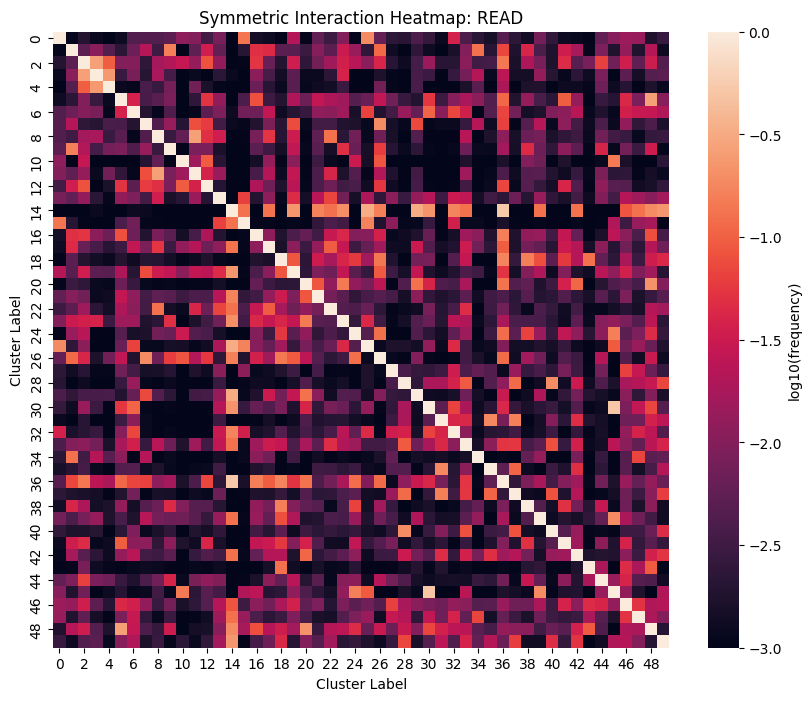

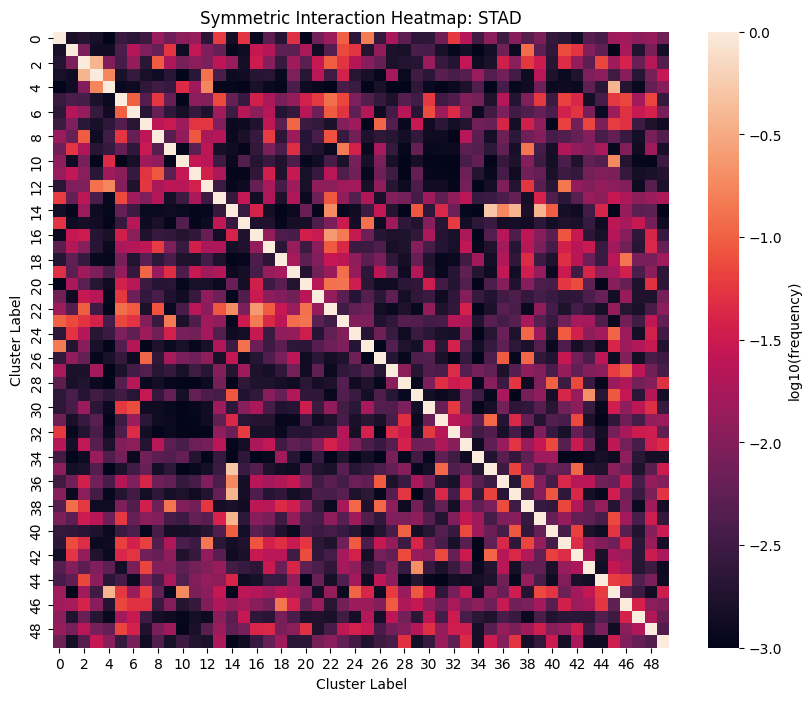

In [11]:

# Get the list of cancer types
cancer_types = merged_df['cancer_type'].unique()
all_clusters = range(50)

for ct in cancer_types:
    # 1. Filter for the specific cancer type
    subset = merged_df[merged_df['cancer_type'] == ct]
    
    # 2. Pivot to a matrix format
    # Rows = cluster 1, Columns = cluster 2
    matrix = subset.pivot(index='cluster 1', columns='cluster 2', values='frequency')
    
    # 3. Ensure the matrix is exactly 50x50
    matrix = matrix.reindex(index=all_clusters, columns=all_clusters, fill_value=0)
    
    # 4. Symmetrize the matrix
    # This copies the upper triangle to the lower triangle
    # matrix.T is the transpose; adding them fills both halves
    full_matrix = matrix.add(matrix.T, fill_value=0)
    
    # 5. Set the diagonal to 1
    np.fill_diagonal(full_matrix.values, 1)
    
    # 6. Create the plot
    plt.figure(figsize=(10, 8))
    
    # Using log10 for better contrast, adding a small constant to avoid log(0)
    log_data = np.log10(full_matrix + 0.001)
    
    sns.heatmap(log_data, 
                cmap='rocket', 
                square=True,
                cbar_kws={'label': 'log10(frequency)'})
    
    plt.title(f"Symmetric Interaction Heatmap: {ct.upper()}")
    plt.xlabel("Cluster Label")
    plt.ylabel("Cluster Label")
    plt.savefig(f"png/{ct.upper()}.png")
    plt.show()
    

In [13]:
# Pivot the table so each cancer type is a column
pivoted = merged_df.pivot(index=['cluster 1', 'cluster 2'], 
                         columns='cancer_type', 
                         values='frequency').fillna(0)

# 'pivoted' now has columns: 'coad', 'stad', 'esca', etc.

In [14]:
pivoted

cancer_type              coad      esca      paad      read      stad
cluster 1 cluster 2                                                  
0         1          0.000041  0.010939  0.000134  0.000110  0.000602
          2          0.000734  0.000277  0.003690  0.000929  0.000951
          3          0.000156  0.000086  0.000205  0.000195  0.000582
          4          0.002379  0.000000  0.000000  0.000000  0.000000
          5          0.000253  0.019718  0.004590  0.000284  0.001844
...                       ...       ...       ...       ...       ...
46        48         0.019570  0.018151  0.016955  0.018541  0.009889
          49         0.008160  0.011506  0.008605  0.020525  0.008178
47        48         0.043407  0.035796  0.019724  0.017596  0.019131
          49         0.004352  0.013027  0.001483  0.008929  0.005192
48        49         0.005887  0.001953  0.001496  0.000964  0.003264

[1225 rows x 5 columns]

In [21]:
import itertools
import numpy

cancer_types = pivoted.columns.tolist()
pairs = list(itertools.combinations(cancer_types, 2))

diff_df = pd.DataFrame(index=pivoted.index)

for c1, c2 in pairs:
    col_name = f"{c1}_vs_{c2}"
    # Calculate difference
    diff = pivoted[c1] - pivoted[c2]
    diff_df[col_name] = abs(diff)


In [22]:
diff_df

coad_vs_esca  coad_vs_paad  coad_vs_read  coad_vs_stad  \
cluster 1 cluster 2                                                           
0         1              0.010898      0.000093      0.000068      0.000561   
          2              0.000458      0.002956      0.000194      0.000217   
          3              0.000070      0.000049      0.000038      0.000425   
          4              0.002379      0.002379      0.002379      0.002379   
          5              0.019465      0.004337      0.000031      0.001591   
...                           ...           ...           ...           ...   
46        48             0.001420      0.002615      0.001029      0.009681   
          49             0.003346      0.000445      0.012365      0.000018   
47        48             0.007611      0.023682      0.025811      0.024276   
          49             0.008674      0.002869      0.004576      0.000840   
48        49             0.003934      0.004391      0.004923      0.002623   

                     esca_vs_paad  esca_vs_read  esca_vs_stad  paad_vs_read  \
cluster 1 cluster 2                                                           
0         1              0.010805      0.010829      0.010337      0.000024   
          2              0.003413      0.000652      0.000675      0.002761   
          3              0.000119      0.000108      0.000495      0.000011   
          4              0.000000      0.000000      0.000000      0.000000   
          5              0.015129      0.019435      0.017875      0.004306   
...                           ...           ...           ...           ...   
46        48             0.001196      0.000390      0.008261      0.001586   
          49             0.002901      0.009019      0.003327      0.011920   
47        48             0.016071      0.018199      0.016665      0.002128   
          49             0.011544      0.004098      0.007835      0.007446   
48        49             0.000457      0.000989      0.001311      0.000532   

                     paad_vs_stad  read_vs_stad  
cluster 1 cluster 2                              
0         1              0.000468      0.000493  
          2              0.002739      0.000023  
          3              0.000376      0.000387  
          4              0.000000      0.000000  
          5              0.002746      0.001560  
...                           ...           ...  
46        48             0.007066      0.008652  
          49             0.000427      0.012347  
47        48             0.000594      0.001535  
          49             0.003709      0.003736  
48        49             0.001768      0.002300  

[1225 rows x 10 columns]

In [23]:
noisy_clusters = [0,3,4,7,21,27,34,39,45,46] #filter out the noisy clusters 
# Create a mask for rows where BOTH indices are 'clean'
mask = (~diff_df.index.get_level_values('cluster 1').isin(noisy_clusters)) & \
       (~diff_df.index.get_level_values('cluster 2').isin(noisy_clusters))
filtered_diff_df = diff_df[mask]

In [16]:
filtered_diff_df

coad_vs_esca  coad_vs_paad  coad_vs_read  coad_vs_stad  \
cluster 1 cluster 2                                                           
1         2              0.004125      0.018982      0.006535      0.003044   
          5              0.002916      0.005748      0.006467      0.004751   
          6              0.000110      0.003057      0.009941      0.004791   
          8              0.023827      0.003241      0.008117      0.004852   
          9              0.100164      0.097245      0.054284      0.051583   
...                           ...           ...           ...           ...   
44        48             0.014306      0.013244      0.019479      0.015071   
          49             0.000571      0.001028      0.000242      0.000317   
47        48             0.007611      0.023682      0.025811      0.024276   
          49             0.008674      0.002869      0.004576      0.000840   
48        49             0.003934      0.004391      0.004923      0.002623   

                     esca_vs_paad  esca_vs_read  esca_vs_stad  paad_vs_read  \
cluster 1 cluster 2                                                           
1         2              0.023107      0.002409      0.001081      0.025517   
          5              0.008664      0.003551      0.001835      0.012215   
          6              0.002947      0.010051      0.004681      0.012998   
          8              0.027067      0.031943      0.028678      0.004876   
          9              0.002919      0.154447      0.048580      0.151529   
...                           ...           ...           ...           ...   
44        48             0.027550      0.033785      0.029377      0.006235   
          49             0.000456      0.000813      0.000888      0.001269   
47        48             0.016071      0.018199      0.016665      0.002128   
          49             0.011544      0.004098      0.007835      0.007446   
48        49             0.000457      0.000989      0.001311      0.000532   

                     paad_vs_stad  read_vs_stad  
cluster 1 cluster 2                              
1         2              0.022026      0.003491  
          5              0.010499      0.001716  
          6              0.001734      0.014732  
          8              0.001611      0.003265  
          9              0.045662      0.105867  
...                           ...           ...  
44        48             0.001827      0.004408  
          49             0.001345      0.000075  
47        48             0.000594      0.001535  
          49             0.003709      0.003736  
48        49             0.001768      0.002300  

[780 rows x 10 columns]

In [16]:
import itertools
cancer_types = pivoted.columns.tolist()
pairs = list(itertools.combinations(cancer_types, 2))

normalized_diff_df = pd.DataFrame(index=pivoted.index)
epsilon = 1e-10 

for c1, c2 in pairs:
    col_name = f"{c1}_vs_{c2}"
    # Calculate difference
    diff = pivoted[c1] - pivoted[c2]
    mean = (pivoted[c1]+pivoted[c2])/2 
    factor = diff/(mean+epsilon) 
    normalized_diff_df[col_name] = abs(factor) 


In [17]:
normalized_diff_df 

coad_vs_esca  coad_vs_paad  coad_vs_read  coad_vs_stad  \
cluster 1 cluster 2                                                           
0         1              1.985014      1.060241      0.908463      1.744234   
          2              0.905807      1.336073      0.233543      0.257445   
          3              0.577888      0.271111      0.217960      1.152291   
          4              2.000000      2.000000      2.000000      2.000000   
          5              1.949355      1.791137      0.115167      1.517574   
...                           ...           ...           ...           ...   
46        48             0.075273      0.143208      0.054016      0.657242   
          49             0.340236      0.053051      0.862110      0.002211   
47        48             0.192197      0.750261      0.846211      0.776368   
          49             0.998249      0.983465      0.689131      0.175981   
48        49             1.003540      1.189496      1.437203      0.573321   

                     esca_vs_paad  esca_vs_read  esca_vs_stad  paad_vs_read  \
cluster 1 cluster 2                                                           
0         1              1.951610      1.960317      1.791286      0.199917   
          2              1.721139      1.082121      1.099172      1.195812   
          3              0.816999      0.771553      1.483255      0.053948   
          4              0.000000      0.000000      0.000000      0.000000   
          5              1.244740      1.943254      1.657972      1.767099   
...                           ...           ...           ...           ...   
46        48             0.068118      0.021279      0.589256      0.089365   
          49             0.288486      0.563172      0.338088      0.818417   
47        48             0.578934      0.681733      0.606807      0.114053   
          49             1.591181      0.373322      0.860040      1.430261   
48        49             0.265055      0.678205      0.502497      0.432591   

                     paad_vs_stad  read_vs_stad  
cluster 1 cluster 2                              
0         1              1.272137      1.384055  
          2              1.180107      0.024267  
          3              0.955829      0.996926  
          4              0.000000      0.000000  
          5              0.853673      1.466483  
...                           ...           ...  
46        48             0.526420      0.608628  
          49             0.050841      0.860309  
47        48             0.030557      0.083569  
          49             1.111359      0.529195  
48        49             0.742819      1.088006  

[1225 rows x 10 columns]

In [36]:
normalized_diff_df.columns 

Index(['coad_vs_esca', 'coad_vs_paad', 'coad_vs_read', 'coad_vs_stad',
       'esca_vs_paad', 'esca_vs_read', 'esca_vs_stad', 'paad_vs_read',
       'paad_vs_stad', 'read_vs_stad'],
      dtype='object')

In [18]:
normalized_diff_df['average'] = normalized_diff_df.mean(axis=1) 
normalized_diff_df 

coad_vs_esca  coad_vs_paad  coad_vs_read  coad_vs_stad  \
cluster 1 cluster 2                                                           
0         1              1.985014      1.060241      0.908463      1.744234   
          2              0.905807      1.336073      0.233543      0.257445   
          3              0.577888      0.271111      0.217960      1.152291   
          4              2.000000      2.000000      2.000000      2.000000   
          5              1.949355      1.791137      0.115167      1.517574   
...                           ...           ...           ...           ...   
46        48             0.075273      0.143208      0.054016      0.657242   
          49             0.340236      0.053051      0.862110      0.002211   
47        48             0.192197      0.750261      0.846211      0.776368   
          49             0.998249      0.983465      0.689131      0.175981   
48        49             1.003540      1.189496      1.437203      0.573321   

                     esca_vs_paad  esca_vs_read  esca_vs_stad  paad_vs_read  \
cluster 1 cluster 2                                                           
0         1              1.951610      1.960317      1.791286      0.199917   
          2              1.721139      1.082121      1.099172      1.195812   
          3              0.816999      0.771553      1.483255      0.053948   
          4              0.000000      0.000000      0.000000      0.000000   
          5              1.244740      1.943254      1.657972      1.767099   
...                           ...           ...           ...           ...   
46        48             0.068118      0.021279      0.589256      0.089365   
          49             0.288486      0.563172      0.338088      0.818417   
47        48             0.578934      0.681733      0.606807      0.114053   
          49             1.591181      0.373322      0.860040      1.430261   
48        49             0.265055      0.678205      0.502497      0.432591   

                     paad_vs_stad  read_vs_stad   average  
cluster 1 cluster 2                                        
0         1              1.272137      1.384055  1.425728  
          2              1.180107      0.024267  0.903549  
          3              0.955829      0.996926  0.729776  
          4              0.000000      0.000000  0.800000  
          5              0.853673      1.466483  1.430645  
...                           ...           ...       ...  
46        48             0.526420      0.608628  0.283281  
          49             0.050841      0.860309  0.417692  
47        48             0.030557      0.083569  0.466069  
          49             1.111359      0.529195  0.874218  
48        49             0.742819      1.088006  0.791274  

[1225 rows x 11 columns]

In [28]:
normalized_diff_df['average'].mean() 

np.float64(1.0061534451532868)

In [40]:
df.index.get_level_values

<bound method MultiIndex.get_level_values of MultiIndex([('paad', ...),
            ('paad', ...),
            ('paad', ...),
            ('paad', ...),
            ('paad', ...),
            ('paad', ...),
            ('paad', ...),
            ('paad', ...),
            ('paad', ...),
            ('paad', ...),
            ...
            ('read', ...),
            ('read', ...),
            ('read', ...),
            ('read', ...),
            ('read', ...),
            ('read', ...),
            ('read', ...),
            ('read', ...),
            ('read', ...),
            ('read', ...)],
           length=85078334)>

In [46]:
# 1. Create a mask for 'cluster 1'
mask1 = normalized_filtered_diff_df.index.get_level_values('cluster 1').astype(str).str.contains('43')

# 2. Create a mask for 'cluster 2'
mask2 = normalized_filtered_diff_df.index.get_level_values('cluster 2').astype(str).str.contains('43')

# 3. Combine them with 'OR' (|) and filter the DataFrame
filtered_df = normalized_filtered_diff_df[mask1 | mask2]
filtered_df 

,,coad_vs_esca,coad_vs_paad,coad_vs_read,coad_vs_stad,esca_vs_paad,esca_vs_read,esca_vs_stad,paad_vs_read,paad_vs_stad,read_vs_stad,average
cluster 1,cluster 2,,,,,,,,,,,
1,43,1.805844,1.331741,0.820153,1.902814,1.188911,1.916413,0.687954,1.690335,1.558238,1.958758,1.486116
2,43,1.806117,1.145443,1.935747,1.891640,1.368425,1.029183,0.586298,1.773261,1.628154,0.521563,1.368583
5,43,1.426546,1.710716,1.999997,1.086377,0.728835,2.000000,0.555324,2.000000,1.166161,1.999999,1.467395
6,43,1.762716,1.856429,0.454958,1.861115,0.515157,1.847307,0.547132,1.908424,0.034399,1.911453,1.269909
8,43,1.854610,1.871999,0.361156,1.862134,0.131693,1.897952,0.055075,1.910278,0.076758,1.903290,1.192495
9,43,1.711056,1.830005,1.533594,1.810834,0.547672,1.959310,0.442689,1.976703,0.111757,1.973963,1.389758
10,43,1.982623,1.566004,2.000000,1.604053,1.861557,1.999998,1.847204,2.000000,0.102281,2.000000,1.696372
11,43,1.817530,1.866837,0.952936,1.805544,0.324940,1.933336,0.066736,1.951746,0.389564,1.928816,1.303798
12,43,1.820181,1.898571,0.458764,1.943243,0.576125,1.885360,1.063300,1.935814,0.575278,1.964234,1.412087


In [47]:
filtered_df['average'].mean() 

np.float64(1.3697657859086103)

In [24]:
normalized_filtered_diff_df = normalized_diff_df[mask]
normalized_filtered_diff_df 

coad_vs_esca  coad_vs_paad  coad_vs_read  coad_vs_stad  \
cluster 1 cluster 2                                                           
1         2              0.480823      0.942797      0.886013      0.333758   
          5              0.466975      0.543411      1.446892      0.891788   
          6              0.007021      0.178297      0.933815      0.265995   
          8              1.073788      0.374434      1.305428      0.618074   
          9              1.850035      1.748985      0.413227      0.657687   
...                           ...           ...           ...           ...   
44        48             0.480459      0.827696      1.511982      0.998903   
          49             0.648146      0.926044      0.509387      0.725124   
47        48             0.192197      0.750261      0.846211      0.776368   
          49             0.998249      0.983465      0.689131      0.175981   
48        49             1.003540      1.189496      1.437203      0.573321   

                     esca_vs_paad  esca_vs_read  esca_vs_stad  paad_vs_read  \
cluster 1 cluster 2                                                           
1         2              1.278705      0.453488      0.153211      1.512873   
          5              0.950112      1.179082      0.474180      1.663348   
          6              0.171329      0.939296      0.259095      1.067671   
          8              1.315948      1.761810      1.451096      1.060598   
          9              0.528839      1.900111      1.713601      1.831324   
...                           ...           ...           ...           ...   
44        48             1.189861      1.686207      1.320879      0.995855   
          49             0.326958      1.069276      1.228881      1.284009   
47        48             0.578934      0.681733      0.606807      0.114053   
          49             1.591181      0.373322      0.860040      1.430261   
48        49             0.265055      0.678205      0.502497      0.432591   

                     paad_vs_stad  read_vs_stad   average  
cluster 1 cluster 2                                        
1         2              1.183456      0.596341  0.782146  
          5              1.280111      0.819439  0.971534  
          6              0.088750      1.129660  0.504093  
          8              0.258602      0.861036  1.008081  
          9              1.531799      1.002782  1.317839  
...                           ...           ...       ...  
44        48             0.215815      0.824331  1.005199  
          49             1.413823      0.237685  0.836934  
47        48             0.030557      0.083569  0.466069  
          49             1.111359      0.529195  0.874218  
48        49             0.742819      1.088006  0.791274  

[780 rows x 11 columns]

In [33]:
normalized_filtered_diff_df.sort_values(by=['average'], ascending=True).head(10)

,,coad_vs_esca,coad_vs_paad,coad_vs_read,coad_vs_stad,esca_vs_paad,esca_vs_read,esca_vs_stad,paad_vs_read,paad_vs_stad,read_vs_stad,average
cluster 1,cluster 2,,,,,,,,,,,
33,40,0.107922,0.163500,0.082800,0.027553,0.055824,0.025178,0.135374,0.080974,0.190837,0.110289,0.098025
25,44,0.136490,0.080016,0.053032,0.021941,0.215917,0.189180,0.114635,0.027013,0.101912,0.074951,0.101509
2,30,0.089213,0.193203,0.169473,0.176210,0.104440,0.257711,0.264384,0.359731,0.366296,0.006789,0.198745
26,33,0.213922,0.300876,0.211421,0.100250,0.088376,0.002529,0.312497,0.090900,0.398124,0.310028,0.202892
12,25,0.215435,0.245610,0.039028,0.437146,0.030580,0.176779,0.227057,0.207079,0.196819,0.399823,0.217535
29,30,0.091325,0.428221,0.338552,0.090218,0.340222,0.249154,0.001109,0.093040,0.341299,0.250245,0.222338
13,49,0.513781,0.504690,0.407188,0.524994,0.009721,0.112475,0.012024,0.102782,0.021745,0.124457,0.233386
2,48,0.046727,0.278622,0.225741,0.173254,0.324294,0.271752,0.126783,0.053726,0.446488,0.395132,0.234252
11,44,0.186864,0.526784,0.174692,0.076683,0.348497,0.012272,0.110576,0.360384,0.454693,0.098337,0.234978


In [36]:
normalized_filtered_diff_df.sort_values(by=['average'], ascending=False).head(10)

coad_vs_esca  coad_vs_paad  coad_vs_read  coad_vs_stad  \
cluster 1 cluster 2                                                           
10        29             1.985197      0.764824      2.000000      1.897435   
14        41             0.440226      1.906081      2.000000      1.989079   
          24             0.933333      1.907585      2.000000      1.980105   
          19             2.000000      1.970767      0.651828      1.992002   
10        23             0.000000      2.000000      1.999991      1.999999   
14        40             1.414634      1.983144      2.000000      1.676966   
26        31             1.960747      1.999991      0.584090      1.721914   
13        14             1.999982      2.000000      0.000000      2.000000   
14        33             2.000000      1.988957      0.731278      1.993974   
          49             0.709677      1.961876      1.174603      1.998443   

                     esca_vs_paad  esca_vs_read  esca_vs_stad  paad_vs_read  \
cluster 1 cluster 2                                                           
10        29             1.967016      1.999995      1.505235      2.000000   
14        41             1.939455      2.000000      1.993012      2.000000   
          24             1.755734      2.000000      1.945760      2.000000   
          19             2.000000      2.000000      1.999998      1.985085   
10        23             2.000000      1.999991      1.999999      1.999635   
14        40             1.997100      2.000000      0.644667      1.999989   
26        31             2.000000      1.978396      1.531568      1.999984   
13        14             1.990155      1.999982      1.946440      2.000000   
14        33             1.999998      2.000000      1.999995      1.994863   
          49             1.920770      1.559322      1.996732      1.990017   

                     paad_vs_stad  read_vs_stad   average  
cluster 1 cluster 2                                        
10        29             1.777484      1.999999  1.789718  
14        41             1.591104      1.999999  1.785896  
          24             1.302075      1.999999  1.782459  
          19             1.144323      1.995930  1.773993  
10        23             1.994795      1.738076  1.773249  
14        40             1.998513      2.000000  1.771501  
26        31             1.999999      1.842683  1.761937  
13        14             1.384662      2.000000  1.732122  
14        33             0.589042      1.997199  1.729531  
          49             1.844429      1.999595  1.715546

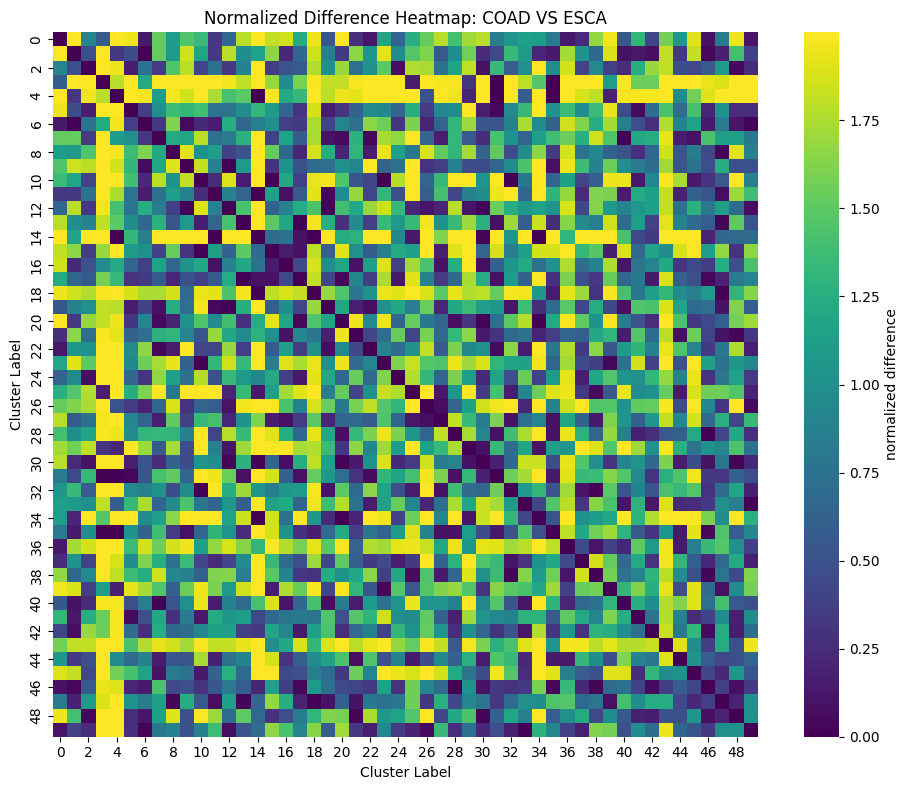

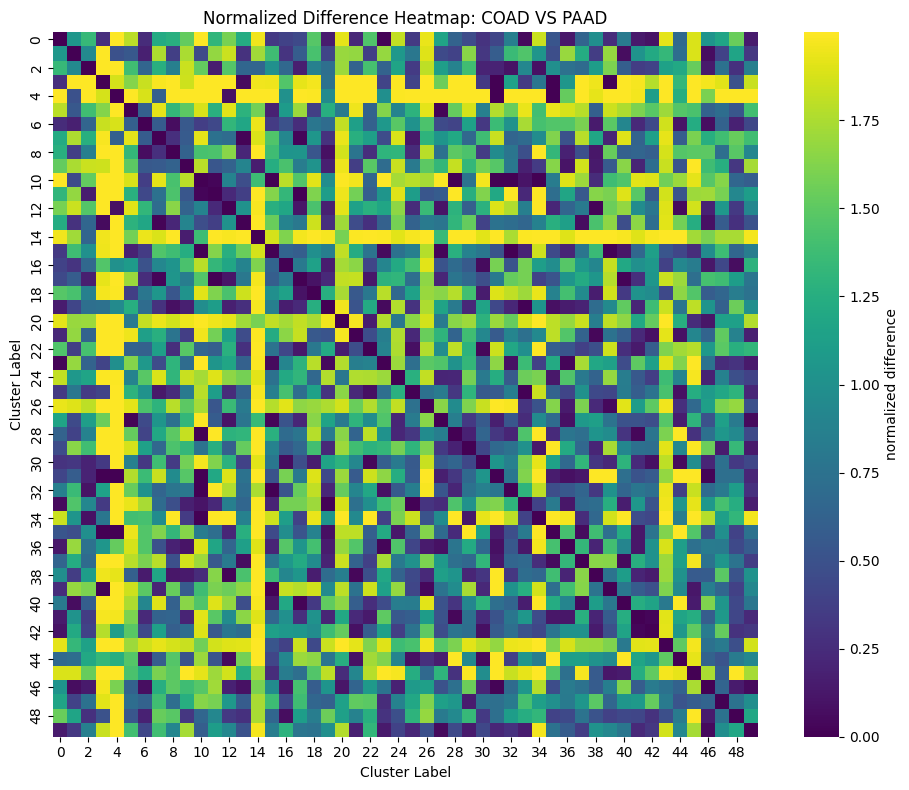

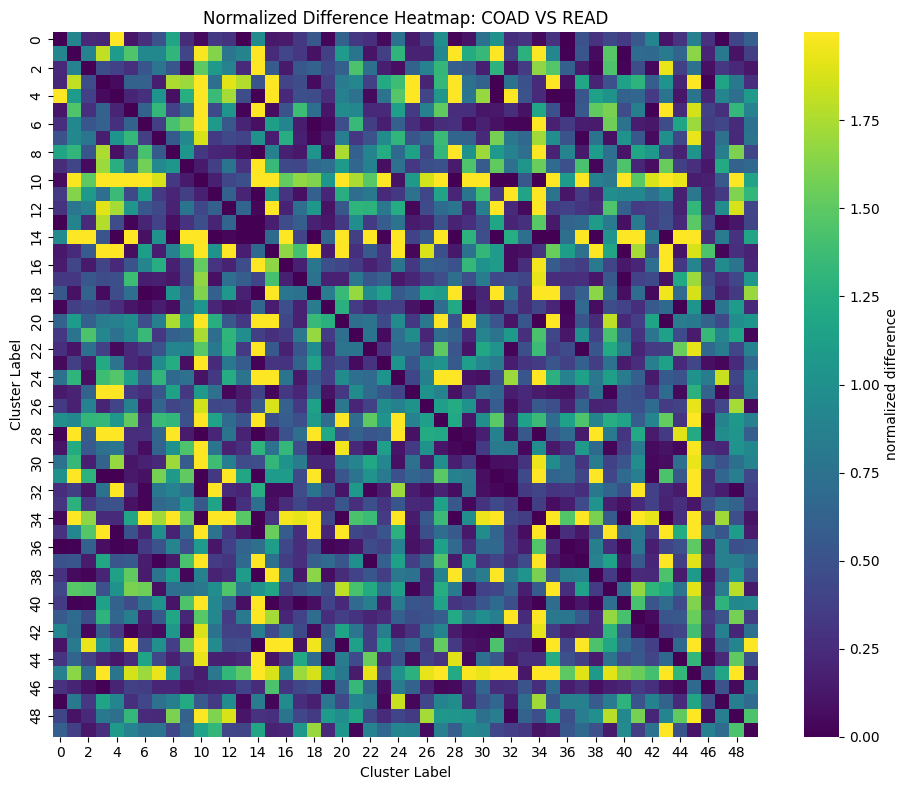

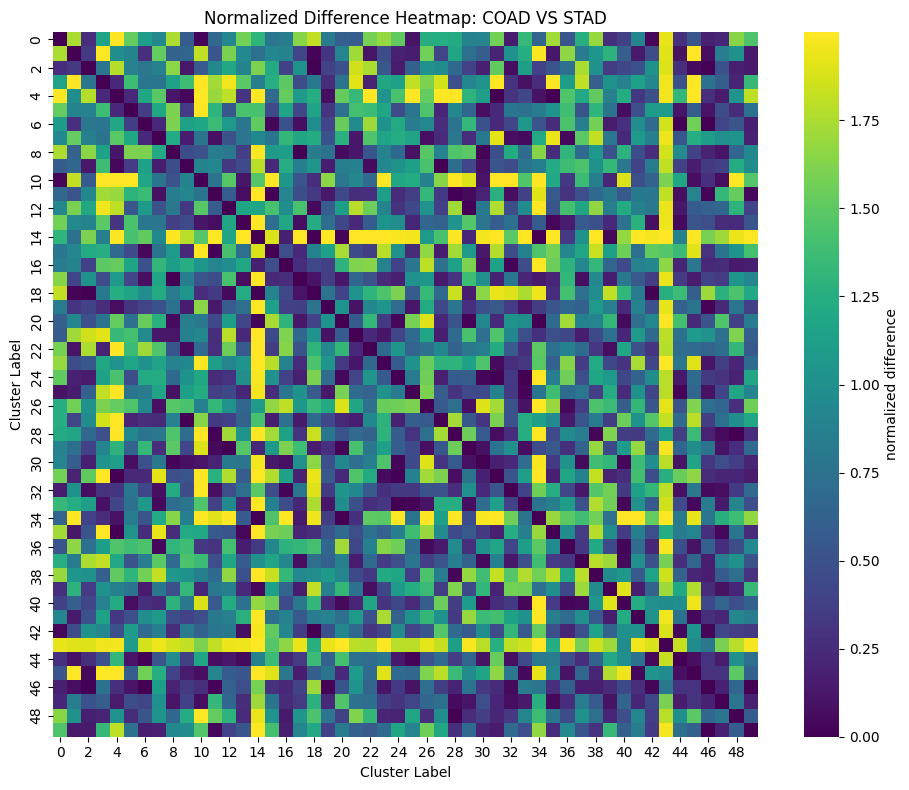

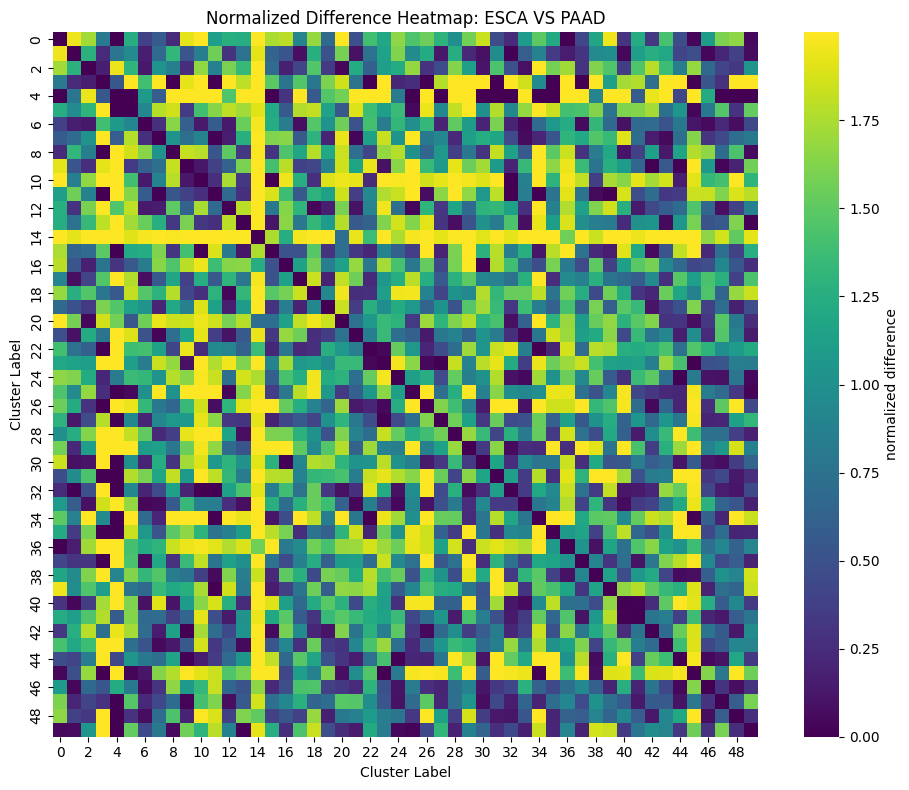

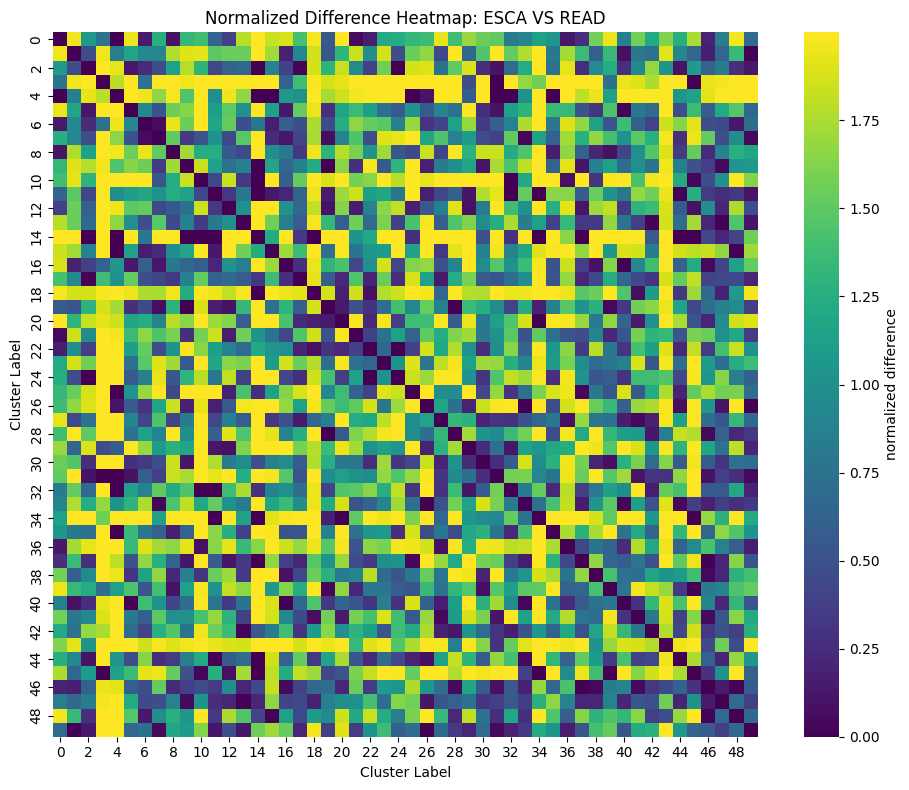

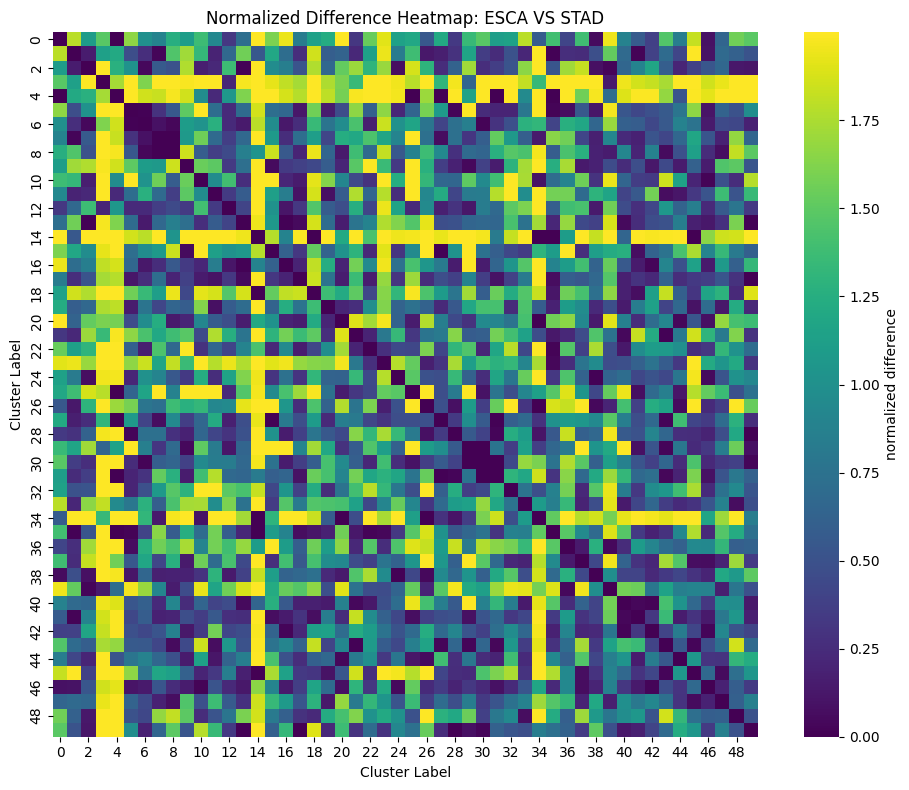

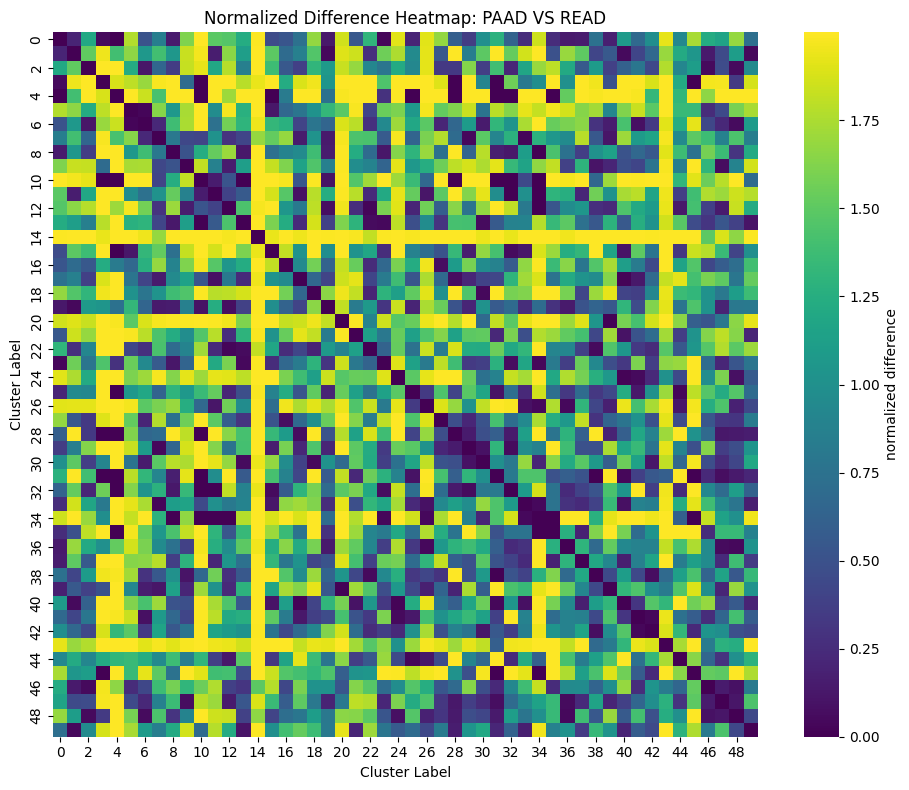

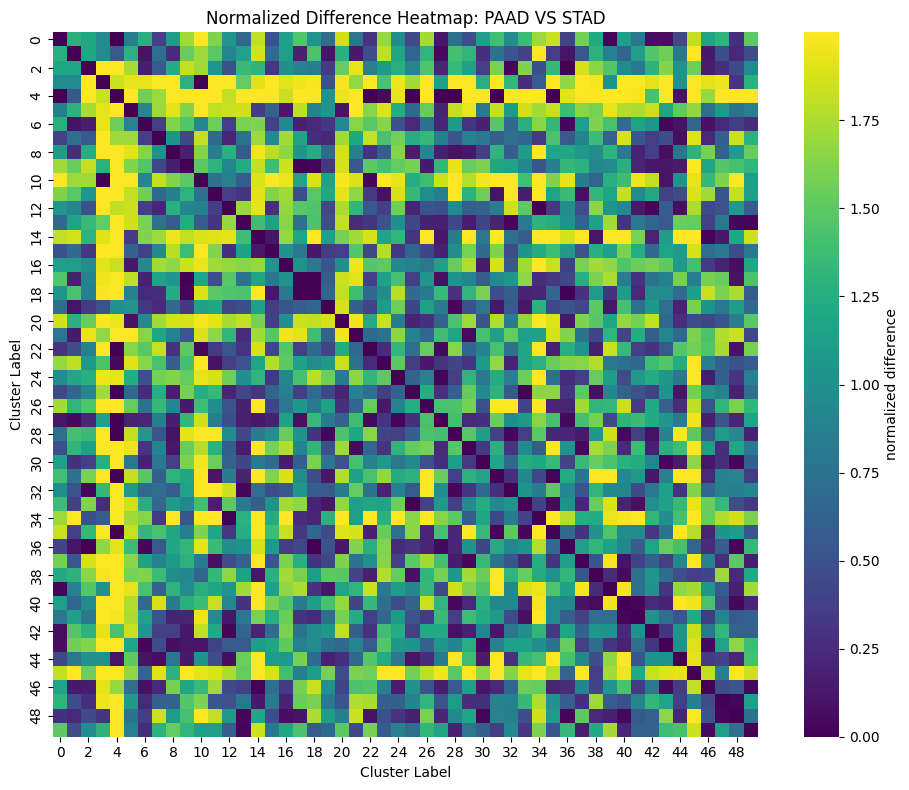

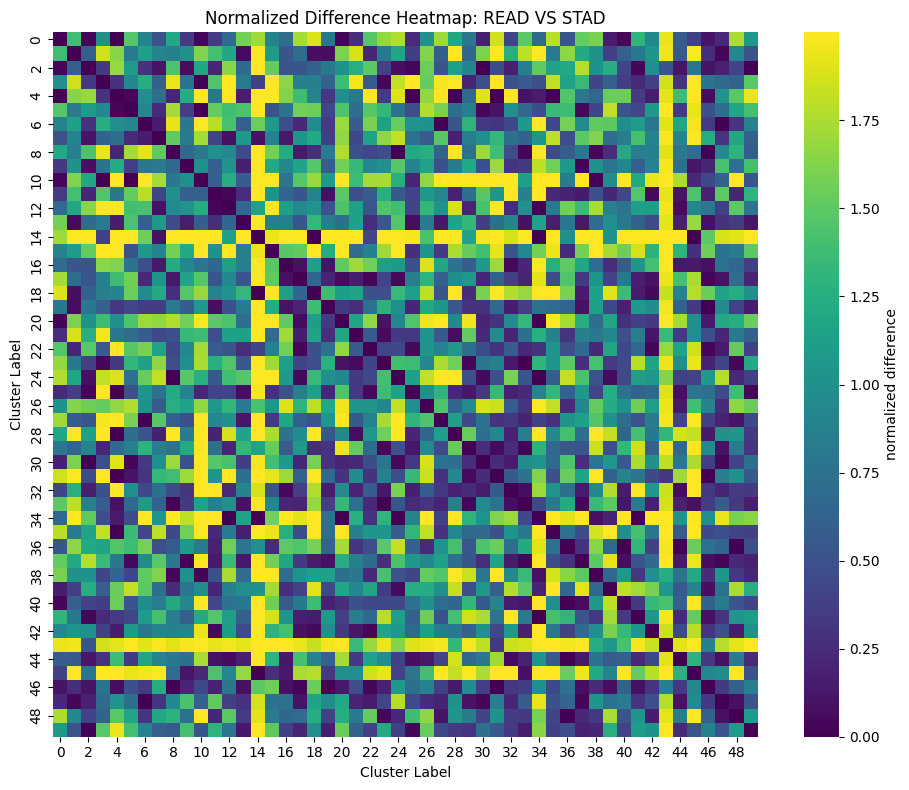

In [29]:

# Assuming 'diff_df' is the dataframe from your screenshot 
# with MultiIndex ['cluster 1', 'cluster 2']
all_clusters = range(50)

# Iterate through each comparison column
for col in normalized_diff_df.columns:
    # 1. Pivot the specific comparison column into a matrix
    # Since it's a Series with a MultiIndex, we use .unstack()
    matrix = normalized_diff_df[col].unstack(level='cluster 2')
    
    # 2. Ensure the matrix is exactly 50x50
    matrix = matrix.reindex(index=all_clusters, columns=all_clusters, fill_value=0)
    
    # 3. Symmetrize the matrix 
    # (Since abs(diff) between A and B is the same as B and A)
    full_matrix = matrix.add(matrix.T, fill_value=0)
    
    # 4. Set the diagonal
    # For a difference map, the diagonal (diff with itself) is usually 0
    np.fill_diagonal(full_matrix.values, 0)
    
    # 5. Create the plot
    plt.figure(figsize=(10, 8))
    
    #log_data = np.log10(full_matrix + 0.001)
    
    sns.heatmap(full_matrix, 
                cmap='viridis', 
                square=True,
                cbar_kws={'label': 'normalized difference'})
    
    plt.title(f"Normalized Difference Heatmap: {col.replace('_', ' ').upper()}")
    plt.xlabel("Cluster Label")
    plt.ylabel("Cluster Label")
    plt.tight_layout()
    plt.savefig(f"png/{col.replace('_',' ').upper()}_norm.png") 
    plt.show()

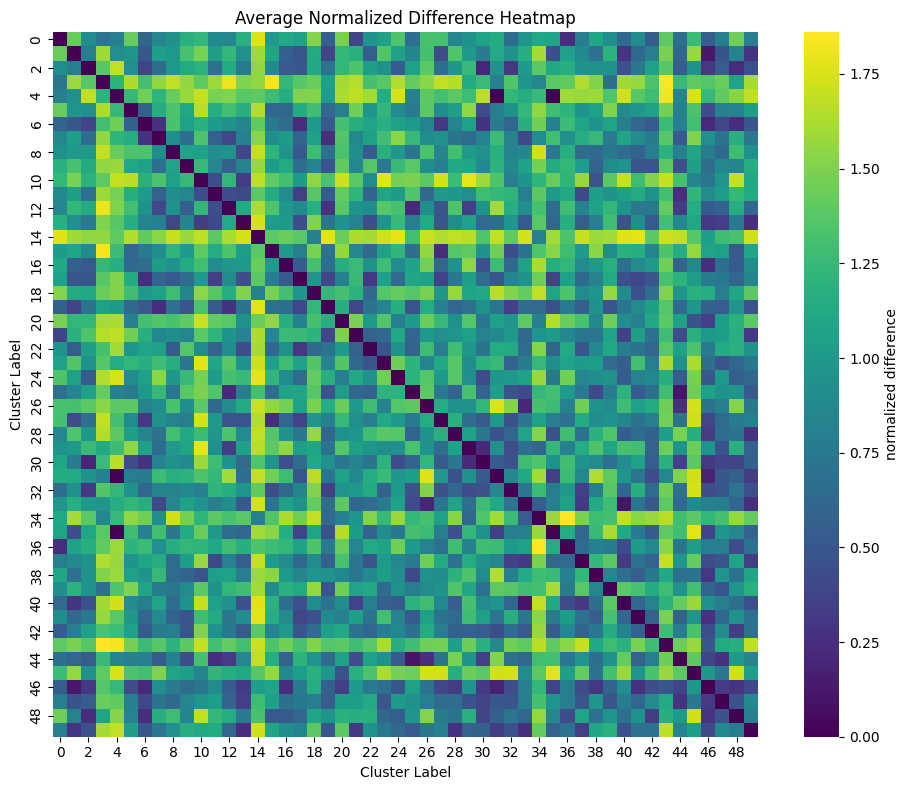

In [41]:

# Assuming 'diff_df' is the dataframe from your screenshot 
# with MultiIndex ['cluster 1', 'cluster 2']
all_clusters = range(50)

# 1. Pivot the specific comparison column into a matrix
# Since it's a Series with a MultiIndex, we use .unstack()
matrix = normalized_diff_df['average'].unstack(level='cluster 2')
    
# 2. Ensure the matrix is exactly 50x50
matrix = matrix.reindex(index=all_clusters, columns=all_clusters, fill_value=0)
    
 # 3. Symmetrize the matrix 
 # (Since abs(diff) between A and B is the same as B and A)
full_matrix = matrix.add(matrix.T, fill_value=0)
    
# 4. Set the diagonal
# For a difference map, the diagonal (diff with itself) is usually 0
np.fill_diagonal(full_matrix.values, 0)
    
 # 5. Create the plot
plt.figure(figsize=(10, 8))
    
#log_data = np.log10(full_matrix + 0.001)
    
sns.heatmap(full_matrix, 
            cmap='viridis', 
            square=True,
            cbar_kws={'label': 'normalized difference'})
    
plt.title("Average Normalized Difference Heatmap")
plt.xlabel("Cluster Label")
plt.ylabel("Cluster Label")
plt.tight_layout()
plt.savefig(f"png/{col.replace('_',' ').upper()}_norm_avg.png") 
plt.show()

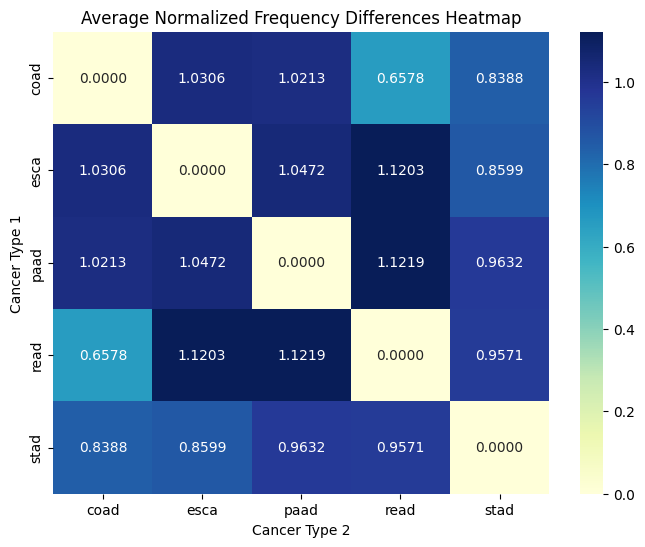

In [31]:
avg_norm_diff_df = normalized_filtered_diff_df.mean()
# 1. Split the index into two separate columns
df_split = avg_norm_diff_df.index.str.split('_vs_', expand=True)

# 2. Create a new DataFrame and pivot it
matrix_df = pd.DataFrame({
    'Cancer Type 1': df_split.get_level_values(0),
    'Cancer Type 2': df_split.get_level_values(1),
    'value': avg_norm_diff_df.values
})

# Create the symmetric matrix
heatmap_data = matrix_df.pivot(index='Cancer Type 1', columns='Cancer Type 2', values='value')

# Optional: Fill the diagonal with 0 (since group_vs_group diff is 0)
# and ensure the matrix is perfectly square (5x5)
all_labels = sorted(list(set(matrix_df['Cancer Type 1']) | set(matrix_df['Cancer Type 2'])))
heatmap_data = heatmap_data.reindex(index=all_labels, columns=all_labels).fillna(0)

# Optional: Mirror the data if you want a full matrix instead of just half
heatmap_data = heatmap_data + heatmap_data.T

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt='.4f')
plt.title('Average Normalized Frequency Differences Heatmap')
plt.savefig('png/avg_norm_freq_diff_heatmap.png')
plt.show()

In [44]:
conserved = normalized_filtered_diff_df.sort_values('average', ascending = True) 
conserved.head(10)

,,coad_vs_esca,coad_vs_paad,coad_vs_read,coad_vs_stad,esca_vs_paad,esca_vs_read,esca_vs_stad,paad_vs_read,paad_vs_stad,read_vs_stad,average
cluster 1,cluster 2,,,,,,,,,,,
33,40,0.107922,0.163500,0.082800,0.027553,0.055824,0.025178,0.135374,0.080974,0.190837,0.110289,0.098025
25,44,0.136490,0.080016,0.053032,0.021941,0.215917,0.189180,0.114635,0.027013,0.101912,0.074951,0.101509
2,30,0.089213,0.193203,0.169473,0.176210,0.104440,0.257711,0.264384,0.359731,0.366296,0.006789,0.198745
26,33,0.213922,0.300876,0.211421,0.100250,0.088376,0.002529,0.312497,0.090900,0.398124,0.310028,0.202892
12,25,0.215435,0.245610,0.039028,0.437146,0.030580,0.176779,0.227057,0.207079,0.196819,0.399823,0.217535
29,30,0.091325,0.428221,0.338552,0.090218,0.340222,0.249154,0.001109,0.093040,0.341299,0.250245,0.222338
13,49,0.513781,0.504690,0.407188,0.524994,0.009721,0.112475,0.012024,0.102782,0.021745,0.124457,0.233386
2,48,0.046727,0.278622,0.225741,0.173254,0.324294,0.271752,0.126783,0.053726,0.446488,0.395132,0.234252
11,44,0.186864,0.526784,0.174692,0.076683,0.348497,0.012272,0.110576,0.360384,0.454693,0.098337,0.234978


In [48]:
varied = normalized_filtered_diff_df.sort_values('average', ascending = False) 
varied.head(10) 

coad_vs_esca  coad_vs_paad  coad_vs_read  coad_vs_stad  \
cluster 1 cluster 2                                                           
10        29             1.985197      0.764824      2.000000      1.897435   
14        41             0.440226      1.906081      2.000000      1.989079   
          24             0.933333      1.907585      2.000000      1.980105   
          19             2.000000      1.970767      0.651828      1.992002   
10        23             0.000000      2.000000      1.999991      1.999999   
14        40             1.414634      1.983144      2.000000      1.676966   
26        31             1.960747      1.999991      0.584090      1.721914   
13        14             1.999982      2.000000      0.000000      2.000000   
14        33             2.000000      1.988957      0.731278      1.993974   
          49             0.709677      1.961876      1.174603      1.998443   

                     esca_vs_paad  esca_vs_read  esca_vs_stad  paad_vs_read  \
cluster 1 cluster 2                                                           
10        29             1.967016      1.999995      1.505235      2.000000   
14        41             1.939455      2.000000      1.993012      2.000000   
          24             1.755734      2.000000      1.945760      2.000000   
          19             2.000000      2.000000      1.999998      1.985085   
10        23             2.000000      1.999991      1.999999      1.999635   
14        40             1.997100      2.000000      0.644667      1.999989   
26        31             2.000000      1.978396      1.531568      1.999984   
13        14             1.990155      1.999982      1.946440      2.000000   
14        33             1.999998      2.000000      1.999995      1.994863   
          49             1.920770      1.559322      1.996732      1.990017   

                     paad_vs_stad  read_vs_stad   average  
cluster 1 cluster 2                                        
10        29             1.777484      1.999999  1.789718  
14        41             1.591104      1.999999  1.785896  
          24             1.302075      1.999999  1.782459  
          19             1.144323      1.995930  1.773993  
10        23             1.994795      1.738076  1.773249  
14        40             1.998513      2.000000  1.771501  
26        31             1.999999      1.842683  1.761937  
13        14             1.384662      2.000000  1.732122  
14        33             0.589042      1.997199  1.729531  
          49             1.844429      1.999595  1.715546

In [19]:

# Create a copy to store the new calculated columns
result_df = filtered_diff_df.copy()

for cancer in cancer_types:
    # Identify columns that contain the specific cancer type (e.g., 'coad_vs_esca')
    relevant_cols = [col for col in filtered_diff_df.columns if cancer in col]
    
    # Calculate the sum across these columns and divide by the number of pairs
    # Note: len(relevant_cols) should be 4 based on your 10-column table
    result_df[f'{cancer}_mean_diff'] = filtered_diff_df[relevant_cols].sum(axis=1) / len(relevant_cols)

# Display the first few rows of the new columns
display_df = result_df[[f'{c}_mean_diff' for c in cancer_types]]
display_df 

coad_mean_diff  esca_mean_diff  paad_mean_diff  \
cluster 1 cluster 2                                                   
1         2                0.008172        0.007681        0.022408   
          5                0.004970        0.004241        0.009281   
          6                0.004475        0.004447        0.005184   
          8                0.010009        0.027879        0.009199   
          9                0.075819        0.076527        0.074338   
...                             ...             ...             ...   
44        48               0.015525        0.026255        0.012214   
          49               0.000539        0.000682        0.001024   
47        48               0.020345        0.014637        0.010619   
          49               0.004240        0.008038        0.006392   
48        49               0.003968        0.001673        0.001787   

                     read_mean_diff  stad_mean_diff  
cluster 1 cluster 2                                  
1         2                0.009488        0.007411  
          5                0.005987        0.004700  
          6                0.011931        0.006485  
          8                0.012050        0.009602  
          9                0.116532        0.062923  
...                             ...             ...  
44        48               0.015977        0.012671  
          49               0.000600        0.000656  
47        48               0.011918        0.010767  
          49               0.004964        0.004030  
48        49               0.002186        0.002000  

[820 rows x 5 columns]

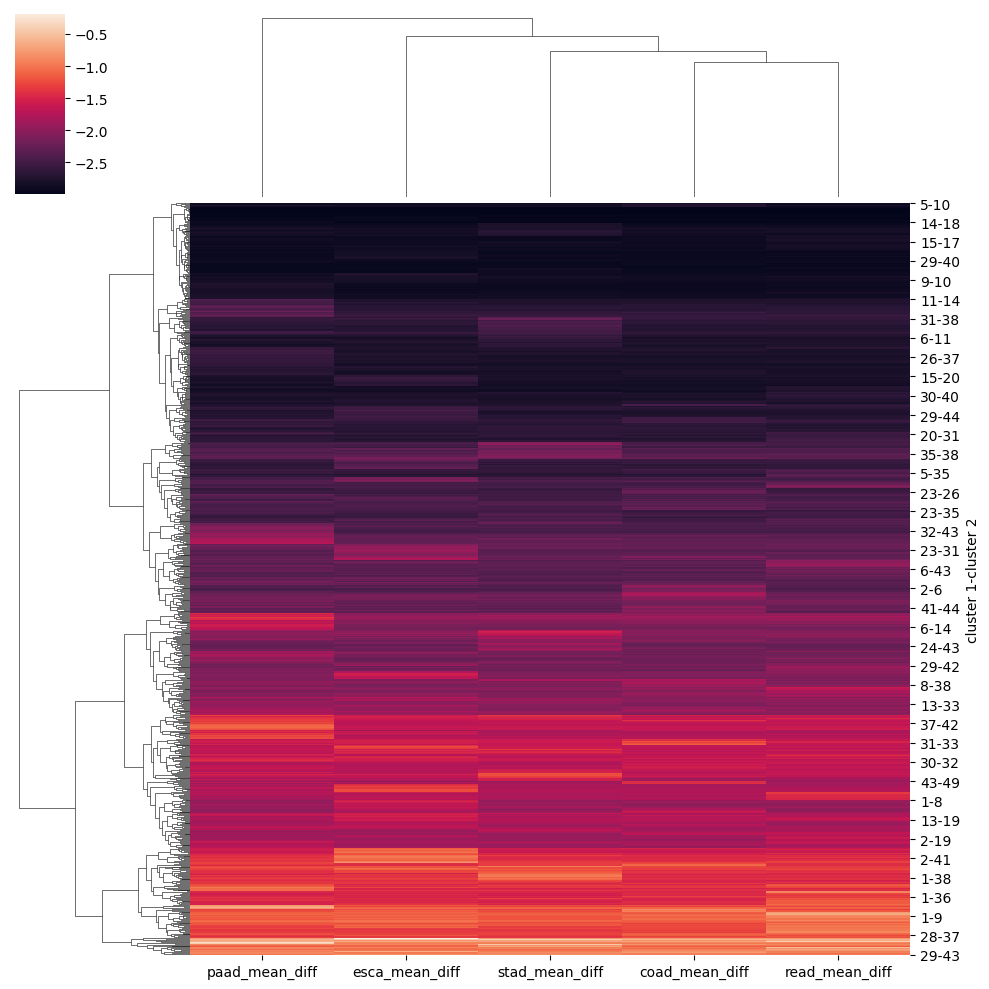

In [20]:
sns.clustermap(np.log10(display_df+ 0.001))

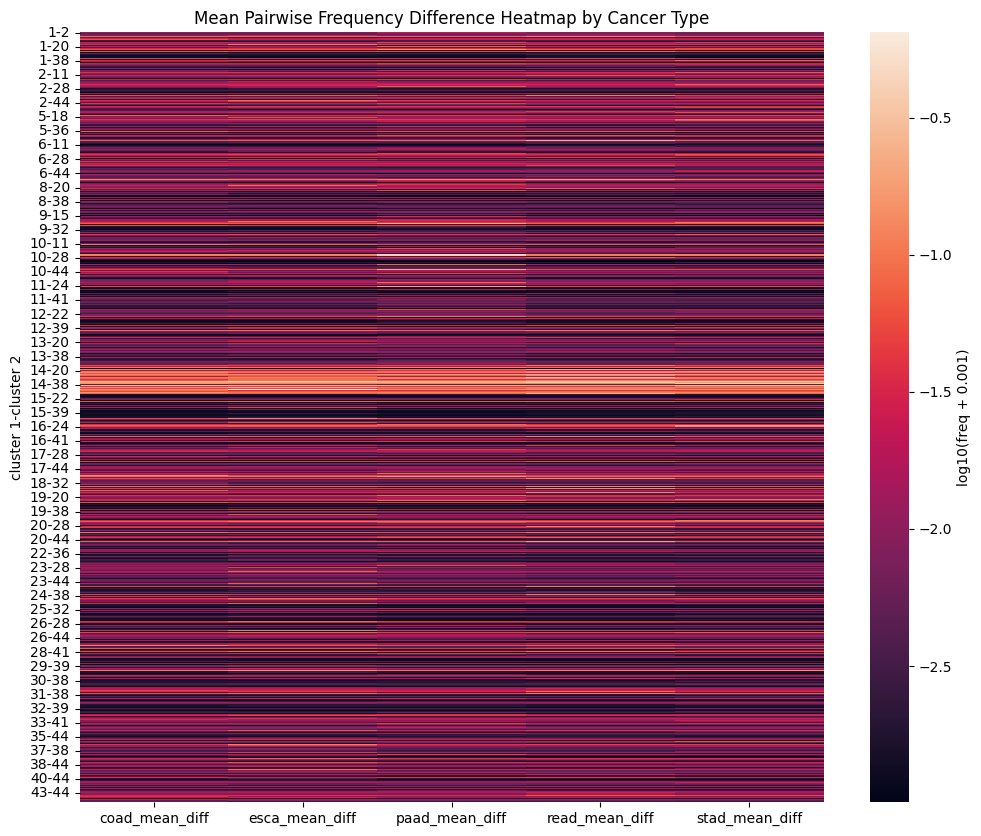

In [21]:
plt.figure(figsize=(12, 10))
sns.heatmap(np.log10(display_df+ 0.001),cmap='rocket',cbar_kws={'label': 'log10(freq + 0.001)'})
plt.title('Mean Pairwise Frequency Difference Heatmap by Cancer Type')
plt.show()

In [17]:

results = {}

for cancer in cancer_types:
    # 1. Identify the 4 columns containing this cancer type
    relevant_cols = [col for col in filtered_diff_df.columns if cancer in col]
    
    # 2. Calculate the grand sum of all values in these columns
    total_sum = filtered_diff_df[relevant_cols].values.sum()
    
    # 3. Calculate total number of entries (rows * 4 columns)
    total_entries = filtered_diff_df[relevant_cols].size
    
    # 4. Calculate the final mean for this cancer type
    results[cancer] = total_sum / total_entries

# Convert to a Series or DataFrame for a clean view
cancer_means = pd.Series(results)
cancer_means 

coad    0.014728
esca    0.017148
paad    0.017336
read    0.017119
stad    0.015361
dtype: float64

In [18]:
coad_esca = filtered_diff_df['coad_vs_esca']
coad_esca.sort_values().tail(20)

cluster 1  cluster 2
1          18           0.112448
14         19           0.115108
15         25           0.116045
36         41           0.120087
20         36           0.123857
14         37           0.125000
           48           0.125000
12         41           0.129034
15         47           0.132295
29         48           0.140321
10         12           0.141869
18         23           0.145544
28         33           0.146303
8          11           0.153564
14         36           0.196385
           23           0.196721
29         43           0.203841
14         39           0.388889
           35           0.500000
           43           0.647482
Name: coad_vs_esca, dtype: float64

In [19]:
avg_diff_df = filtered_diff_df.mean()
avg_diff_df

coad_vs_esca    0.017301
coad_vs_paad    0.016771
coad_vs_read    0.010484
coad_vs_stad    0.014357
esca_vs_paad    0.017045
esca_vs_read    0.020526
esca_vs_stad    0.013722
paad_vs_read    0.019814
paad_vs_stad    0.015713
read_vs_stad    0.017653
dtype: float64

In [20]:
avg_row_diff_df = filtered_diff_df.mean(axis=1) 
avg_row_diff_df 

cluster 1  cluster 2
1          2            0.011032
           5            0.005836
           6            0.006504
           8            0.013748
           9            0.081228
                          ...   
44         48           0.016528
           49           0.000701
47         48           0.013657
           49           0.005533
48         49           0.002323
Length: 820, dtype: float64

In [21]:
avg_row_diff_df.sort_values().head(20)

cluster 1  cluster 2
11         32           0.000009
10         32           0.000011
           28           0.000026
25         44           0.000030
11         28           0.000035
29         37           0.000037
10         31           0.000065
30         44           0.000066
8          32           0.000080
29         30           0.000085
14         18           0.000086
12         25           0.000096
1          49           0.000099
19         35           0.000103
11         37           0.000107
29         35           0.000118
10         35           0.000133
12         15           0.000141
19         37           0.000157
32         38           0.000162
dtype: float64

In [22]:
avg_row_diff_df.sort_values().tail(20)

cluster 1  cluster 2
5          48           0.099234
14         49           0.104183
9          24           0.107104
14         17           0.111225
           30           0.111862
           19           0.113541
           23           0.119316
29         43           0.121345
8          11           0.122365
14         48           0.132275
           41           0.142283
           29           0.145085
10         24           0.159125
14         37           0.175000
           25           0.180114
10         23           0.200130
14         39           0.230521
           36           0.247885
           43           0.259479
           35           0.300000
dtype: float64

In [23]:
# 1. Reset the index to turn 'cluster 1' and 'cluster 2' into regular columns
counts_df = avg_row_diff_df.sort_values().head(20)
df_temp = counts_df.reset_index()

# 2. Combine both columns into one long Series and count them
all_clusters = pd.concat([df_temp['cluster 1'], df_temp['cluster 2']])
cluster_counts = all_clusters.value_counts()

print(cluster_counts)

10    4
32    4
29    3
11    3
35    3
37    3
25    2
30    2
28    2
44    2
19    2
12    2
1     1
14    1
8     1
31    1
18    1
49    1
15    1
38    1
Name: count, dtype: int64


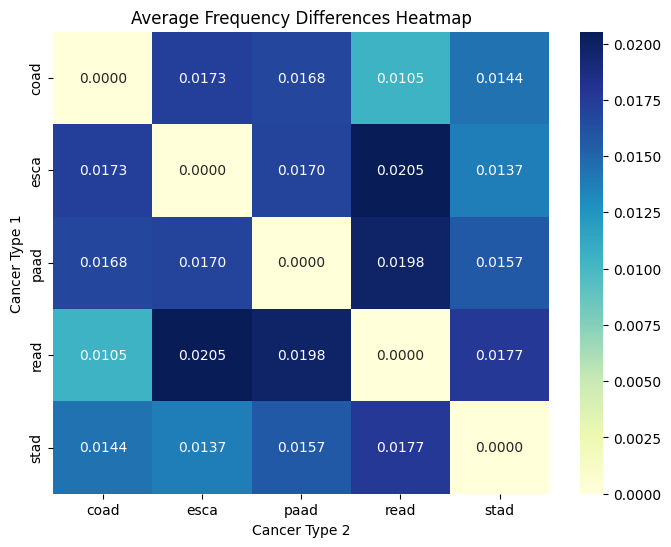

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Split the index into two separate columns
df_split = avg_diff_df.index.str.split('_vs_', expand=True)

# 2. Create a new DataFrame and pivot it
matrix_df = pd.DataFrame({
    'Cancer Type 1': df_split.get_level_values(0),
    'Cancer Type 2': df_split.get_level_values(1),
    'value': avg_diff_df.values
})

# Create the symmetric matrix
heatmap_data = matrix_df.pivot(index='Cancer Type 1', columns='Cancer Type 2', values='value')

# Optional: Fill the diagonal with 0 (since group_vs_group diff is 0)
# and ensure the matrix is perfectly square (5x5)
all_labels = sorted(list(set(matrix_df['Cancer Type 1']) | set(matrix_df['Cancer Type 2'])))
heatmap_data = heatmap_data.reindex(index=all_labels, columns=all_labels).fillna(0)

# Optional: Mirror the data if you want a full matrix instead of just half
heatmap_data = heatmap_data + heatmap_data.T

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt='.4f')
plt.title('Average Frequency Differences Heatmap')
plt.savefig('png/avg_freq_diff_heatmap.png')
plt.show()

In [26]:
for col in new_diff_df.columns: 
    plt.hist(new_diff_df[col], range=[-0.5,0.5],bins=20)
    plt.title(f"Frequency Difference Histogram: {col.replace('_', ' ').upper()}")
    plt.tight_layout()
    plt.show()

NameError: name 'new_diff_df' is not defined

In [25]:
# Assuming 'diff_df' is the dataframe from your screenshot 
# with MultiIndex ['cluster 1', 'cluster 2']
all_clusters = range(50)


# Iterate through each comparison column
for col in avg_row_diff_df.columns:
    # 1. Pivot the specific comparison column into a matrix
    # Since it's a Series with a MultiIndex, we use .unstack()
    matrix = avg_row_diff_df[col].unstack(level='cluster 2')
    
    # 2. Ensure the matrix is exactly 50x50
    matrix = matrix.reindex(index=all_clusters, columns=all_clusters, fill_value=0)
    
    # 3. Symmetrize the matrix 
    # (Since abs(diff) between A and B is the same as B and A)
    full_matrix = matrix.add(matrix.T, fill_value=0)
    
    # 4. Set the diagonal
    # For a difference map, the diagonal (diff with itself) is usually 0
    np.fill_diagonal(full_matrix.values, 0)
    
    # 5. Create the plot
    plt.figure(figsize=(10, 8))
    
    # Apply log10 transformation as requested
    log_data = np.log10(full_matrix + 0.001)
    
    sns.heatmap(log_data, 
                cmap='rocket', # 'viridis' or 'rocket' work well for log scales
                square=True,
                cbar_kws={'label': 'log10(abs_diff + 0.001)'})
    
    plt.title(f"Log Average Absolute Difference Heatmap")
    plt.xlabel("Cluster Label")
    plt.ylabel("Cluster Label")
    plt.tight_layout()
    plt.show()

AttributeError: 'Series' object has no attribute 'columns'

In [28]:
diff_df 

coad_vs_esca  coad_vs_paad  coad_vs_read  coad_vs_stad  \
cluster 1 cluster 2                                                           
0         1              0.010898      0.000093      0.000068      0.000561   
          2              0.000458      0.002956      0.000194      0.000217   
          3              0.000070      0.000049      0.000038      0.000425   
          4              0.002379      0.002379      0.002379      0.002379   
          5              0.019465      0.004337      0.000031      0.001591   
...                           ...           ...           ...           ...   
46        48             0.001420      0.002615      0.001029      0.009681   
          49             0.003346      0.000445      0.012365      0.000018   
47        48             0.007611      0.023682      0.025811      0.024276   
          49             0.008674      0.002869      0.004576      0.000840   
48        49             0.003934      0.004391      0.004923      0.002623   

                     esca_vs_paad  esca_vs_read  esca_vs_stad  paad_vs_read  \
cluster 1 cluster 2                                                           
0         1              0.010805      0.010829      0.010337      0.000024   
          2              0.003413      0.000652      0.000675      0.002761   
          3              0.000119      0.000108      0.000495      0.000011   
          4              0.000000      0.000000      0.000000      0.000000   
          5              0.015129      0.019435      0.017875      0.004306   
...                           ...           ...           ...           ...   
46        48             0.001196      0.000390      0.008261      0.001586   
          49             0.002901      0.009019      0.003327      0.011920   
47        48             0.016071      0.018199      0.016665      0.002128   
          49             0.011544      0.004098      0.007835      0.007446   
48        49             0.000457      0.000989      0.001311      0.000532   

                     paad_vs_stad  read_vs_stad  
cluster 1 cluster 2                              
0         1              0.000468      0.000493  
          2              0.002739      0.000023  
          3              0.000376      0.000387  
          4              0.000000      0.000000  
          5              0.002746      0.001560  
...                           ...           ...  
46        48             0.007066      0.008652  
          49             0.000427      0.012347  
47        48             0.000594      0.001535  
          49             0.003709      0.003736  
48        49             0.001768      0.002300  

[1225 rows x 10 columns]

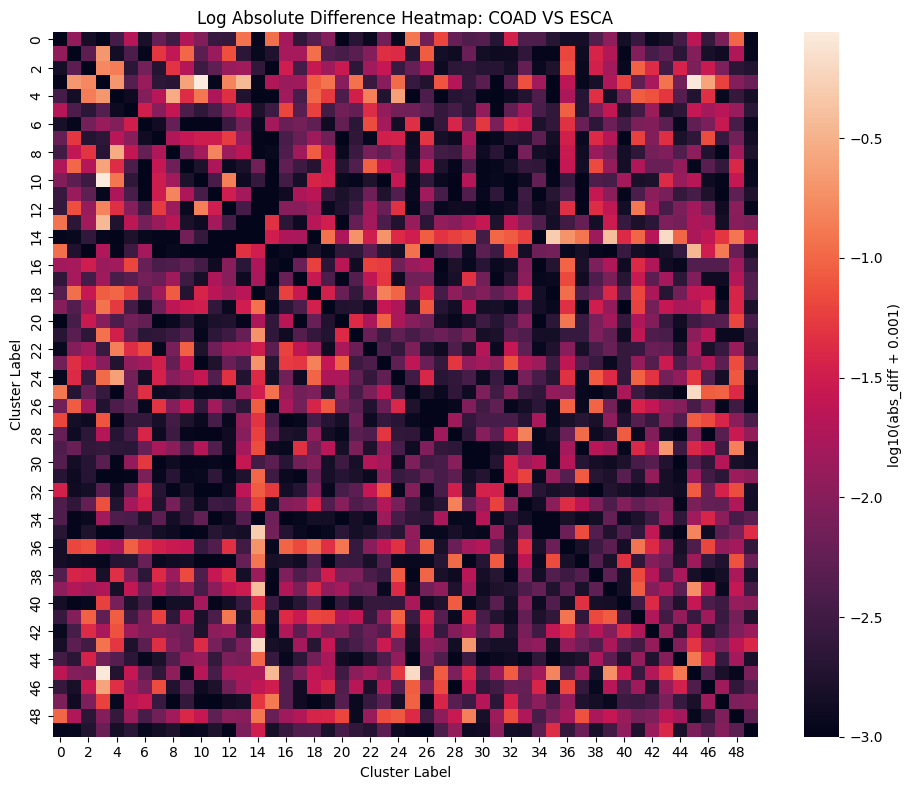

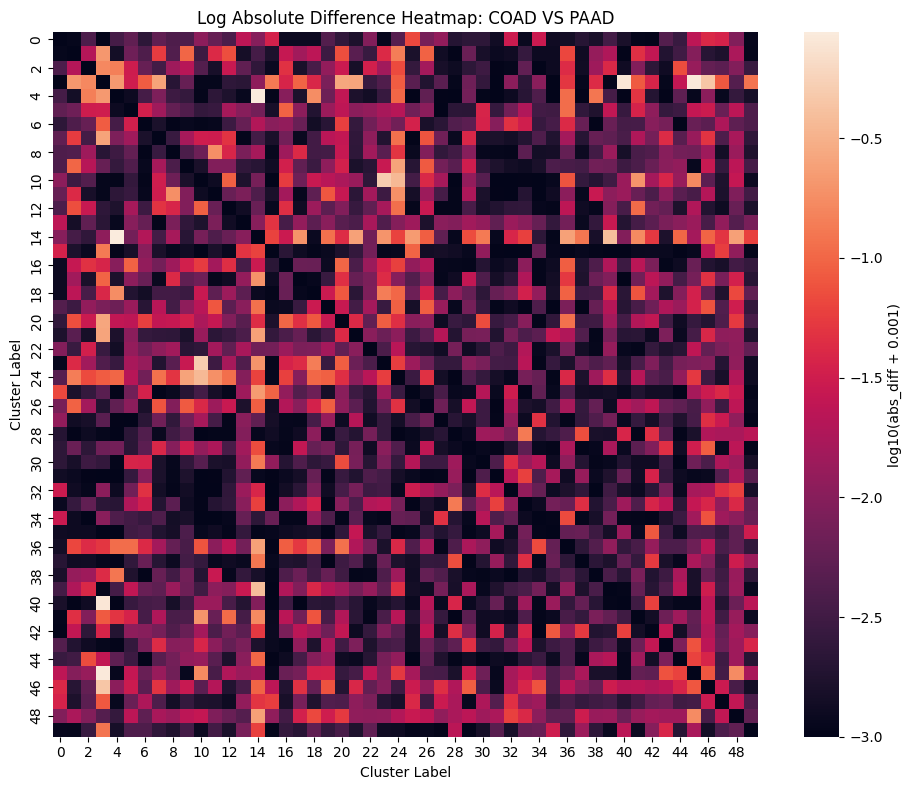

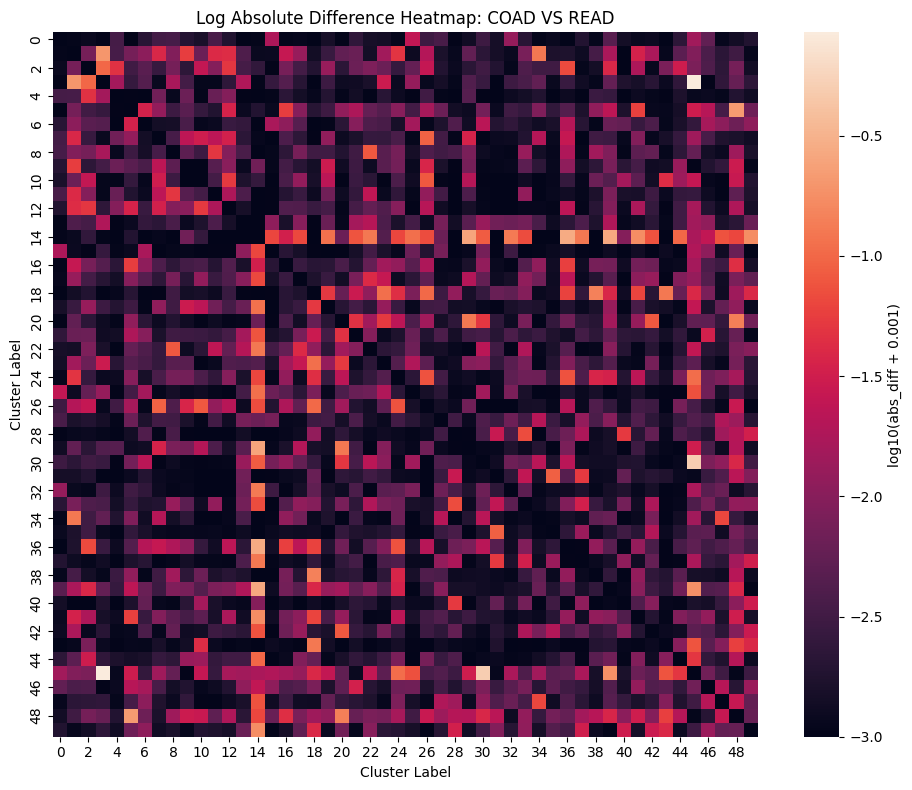

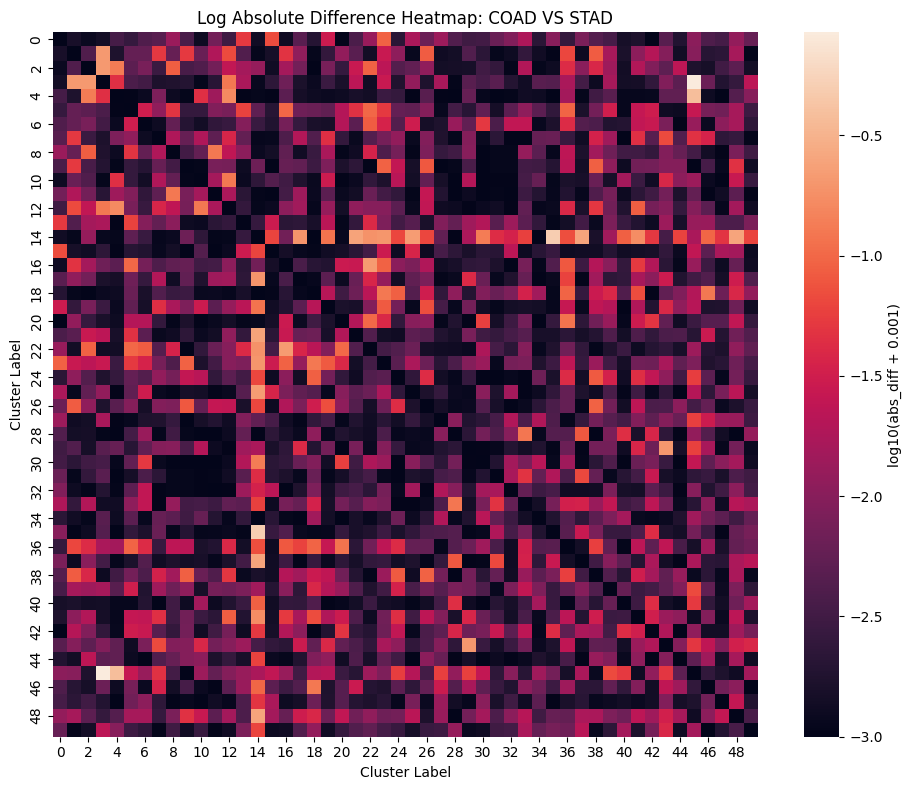

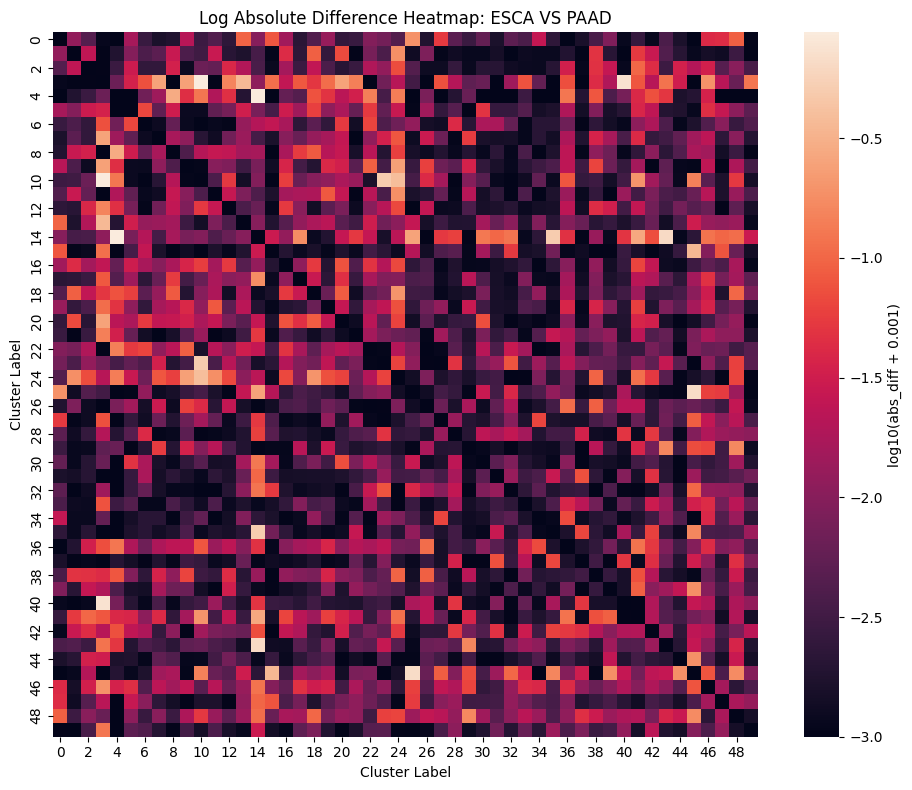

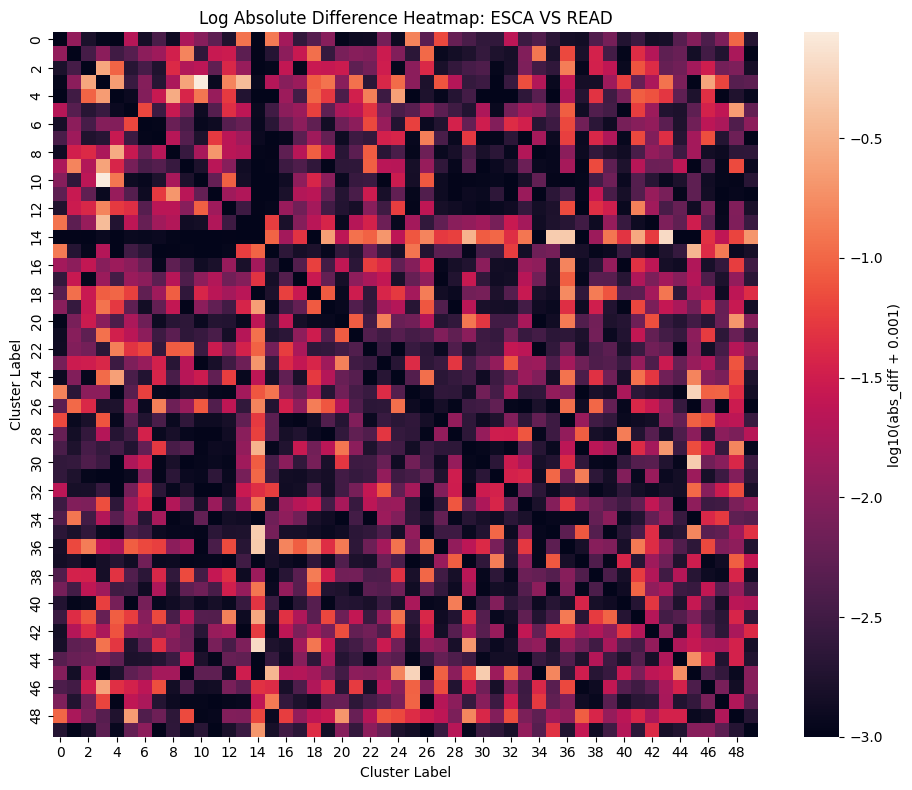

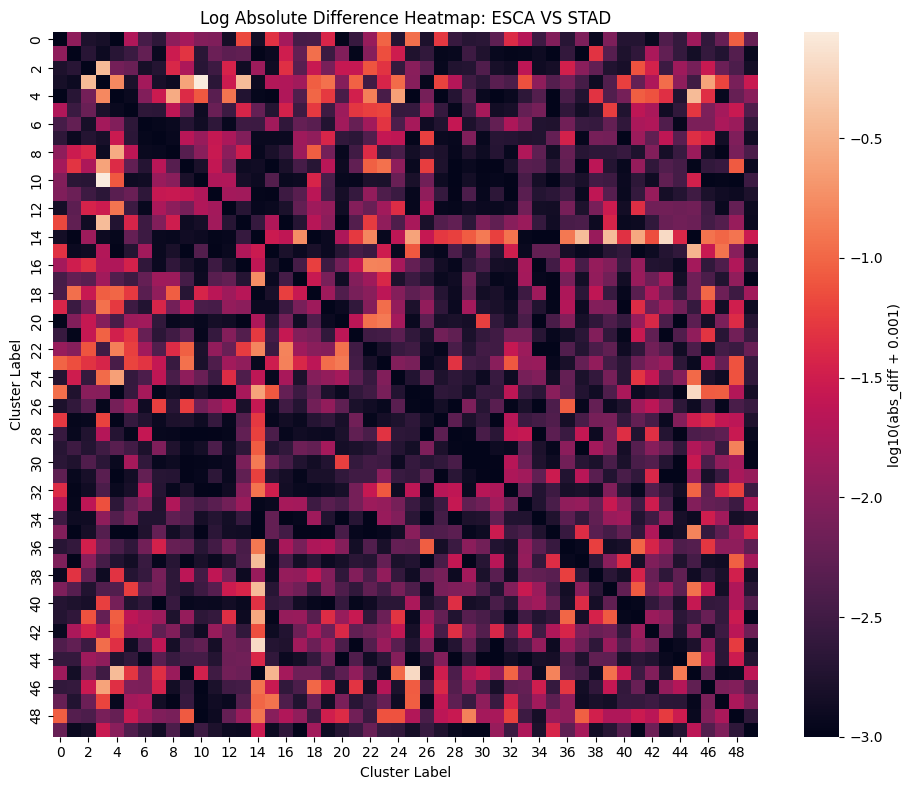

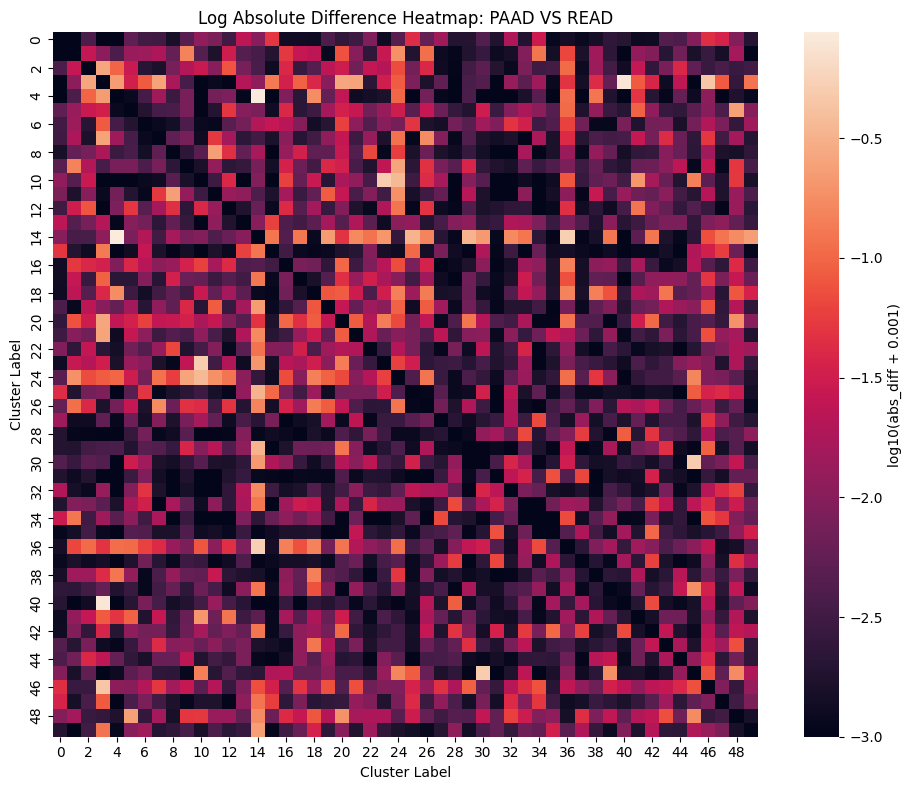

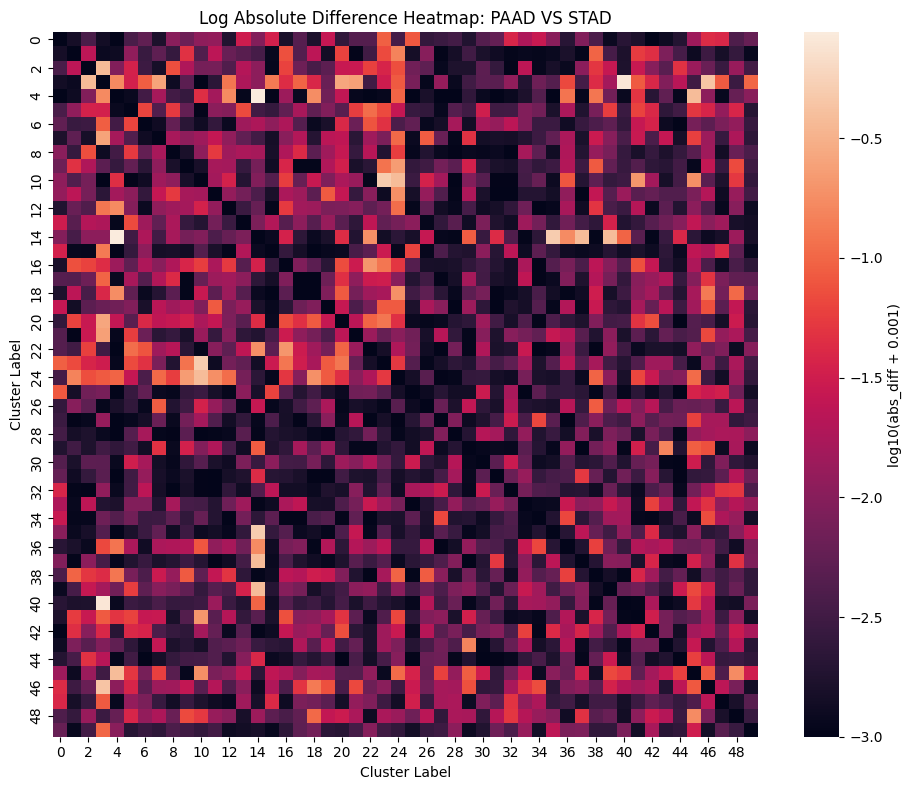

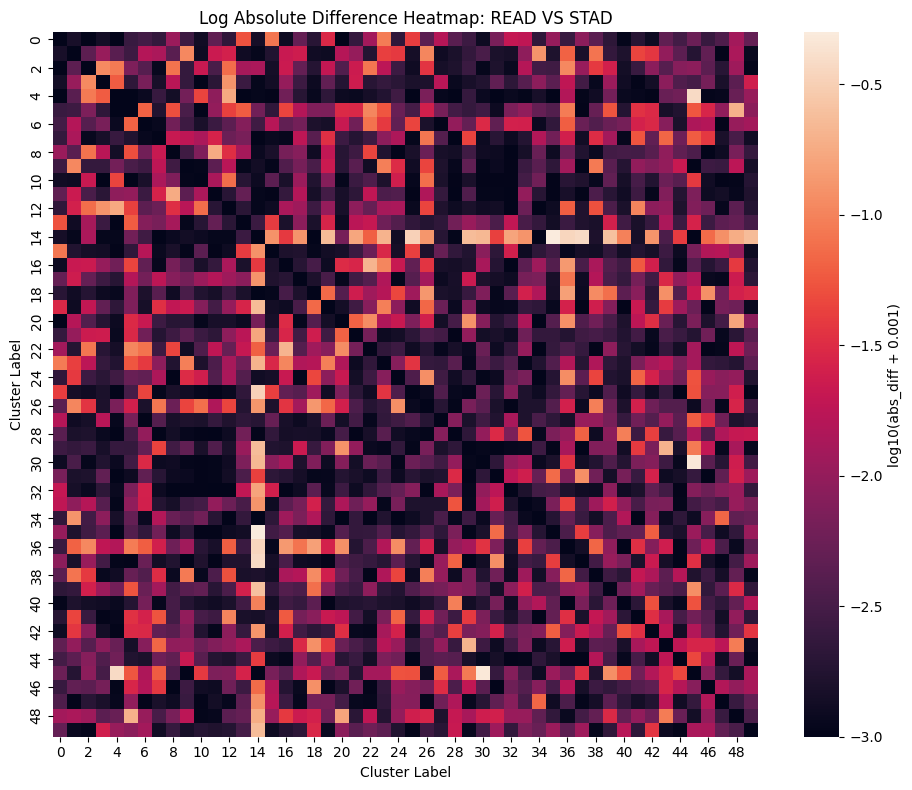

In [29]:

# Assuming 'diff_df' is the dataframe from your screenshot 
# with MultiIndex ['cluster 1', 'cluster 2']
all_clusters = range(50)

# Iterate through each comparison column
for col in diff_df.columns:
    # 1. Pivot the specific comparison column into a matrix
    # Since it's a Series with a MultiIndex, we use .unstack()
    matrix = diff_df[col].unstack(level='cluster 2')
    
    # 2. Ensure the matrix is exactly 50x50
    matrix = matrix.reindex(index=all_clusters, columns=all_clusters, fill_value=0)
    
    # 3. Symmetrize the matrix 
    # (Since abs(diff) between A and B is the same as B and A)
    full_matrix = matrix.add(matrix.T, fill_value=0)
    
    # 4. Set the diagonal
    # For a difference map, the diagonal (diff with itself) is usually 0
    np.fill_diagonal(full_matrix.values, 0)
    
    # 5. Create the plot
    plt.figure(figsize=(10, 8))
    
    # Apply log10 transformation as requested
    log_data = np.log10(full_matrix + 0.001)
    
    sns.heatmap(log_data, 
                cmap='rocket', # 'viridis' or 'rocket' work well for log scales
                square=True,
                cbar_kws={'label': 'log10(abs_diff + 0.001)'})
    
    plt.title(f"Log Absolute Difference Heatmap: {col.replace('_', ' ').upper()}")
    plt.xlabel("Cluster Label")
    plt.ylabel("Cluster Label")
    plt.tight_layout()
    plt.savefig(f"png/{col.replace('_',' ').upper()}.png") 
    plt.show()

In [33]:
noisy_clusters = [0,3,4,7,21,27,34,39,45,46] #filter out the noisy clusters 
filtered_df = summary_df[(~summary_df['cluster 1'].isin(noisy_clusters)) & (~summary_df['cluster 2'].isin(noisy_clusters))] #remove self interaction and noise 
filtered_df

,cancer_type,cluster 1,cluster 2,contact count,total cluster 1,total_c1_interactions,frequency
49,coad,1,2,3739,43957,351321,0.010643
52,coad,1,5,2228,36195,289237,0.007703
53,coad,1,6,4471,35829,286306,0.015616
55,coad,1,8,1612,19618,156871,0.010276
56,coad,1,9,33960,40767,325839,0.104223
...,...,...,...,...,...,...,...
5807,stad,44,48,3816,63961,505297,0.007552
5808,stad,44,49,39,17637,139913,0.000279
5816,stad,47,48,12384,85161,647334,0.019131
5817,stad,47,49,5744,143759,1106262,0.005192


In [34]:
freq_df = filtered_df.set_index(['cluster 1','cluster 2','cancer_type'])['frequency'].unstack().fillna(0)

In [35]:
freq_df

cancer_type              coad      esca      paad      read      stad
cluster 1 cluster 2                                                  
1         2          0.010643  0.006517  0.029625  0.004108  0.007599
          5          0.007703  0.004787  0.013451  0.001236  0.002952
          6          0.015616  0.015726  0.018673  0.005675  0.020407
          8          0.010276  0.034102  0.007035  0.002159  0.005424
          9          0.104223  0.004060  0.006978  0.158507  0.052640
...                       ...       ...       ...       ...       ...
44        48         0.022623  0.036929  0.009379  0.003144  0.007552
          49         0.000596  0.001167  0.001623  0.000354  0.000279
47        48         0.043407  0.035796  0.019724  0.017596  0.019131
          49         0.004352  0.013027  0.001483  0.008929  0.005192
48        49         0.005887  0.001953  0.001496  0.000964  0.003264

[780 rows x 5 columns]

In [68]:
freq_df.mean(axis=0)

cancer_type
coad    0.016793
esca    0.016971
paad    0.014964
read    0.019633
stad    0.015994
dtype: float64

In [36]:
pal = sns.color_palette('tab20',50)
color1 = [pal[a] for a,b in freq_df.index]
color2 = [pal[b] for a,b in freq_df.index]

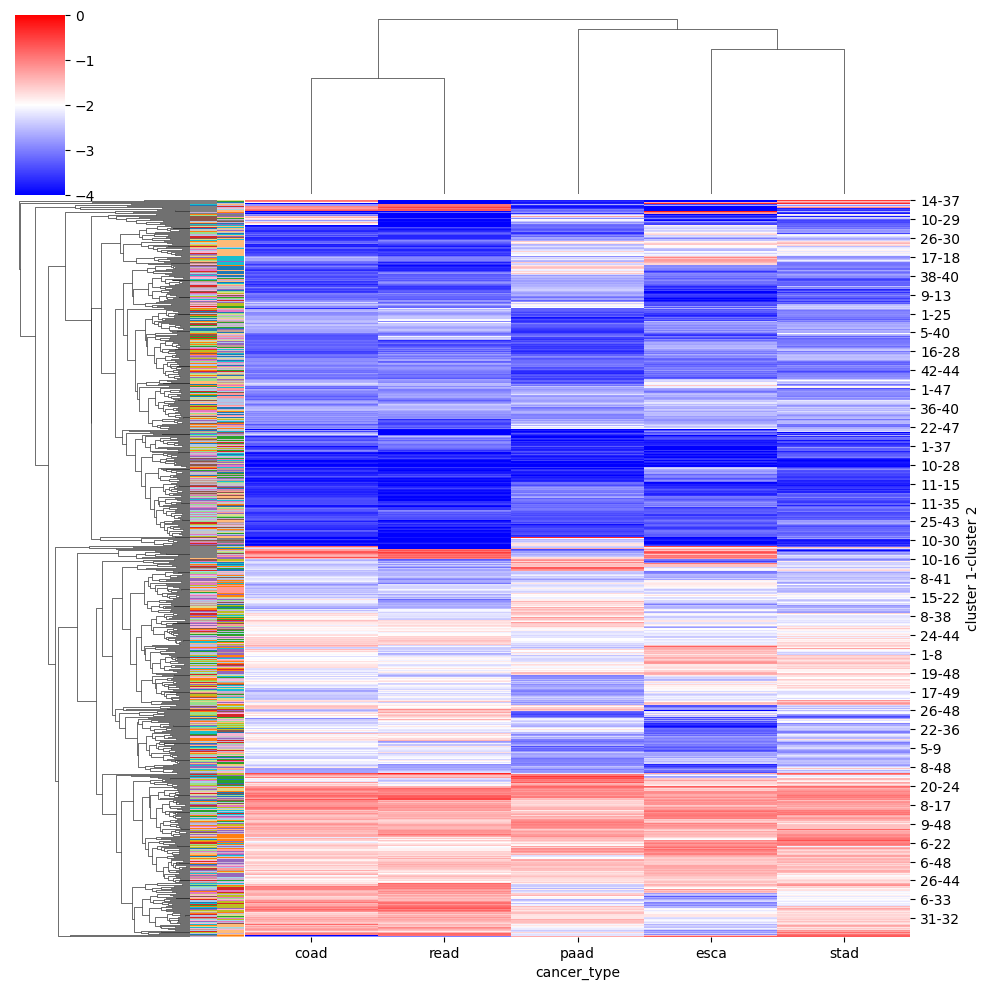

In [37]:
cm = sns.clustermap(np.log10(freq_df+ 0.0001), row_colors = [color1,color2],cmap = 'bwr', vmin = -4, vmax = 0)

In [57]:
clust_colors = [pal[i] for i in fcluster(cm.dendrogram_row.linkage, t = 40, criterion = 'maxclust')]

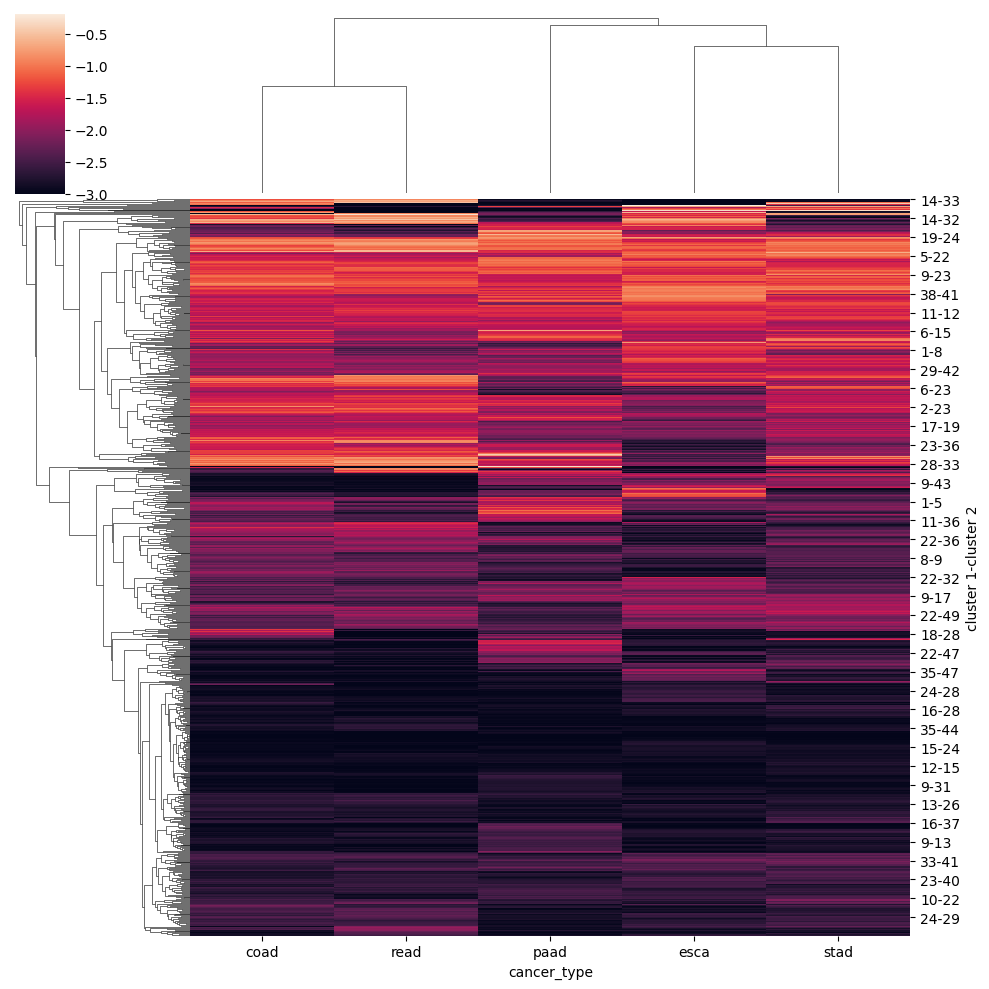

In [59]:
sns.clustermap(np.log10(freq_df+ 0.001))
plt.savefig('png/pairwise_hierarchical_clustermap_no_color.png') 
plt.show() 

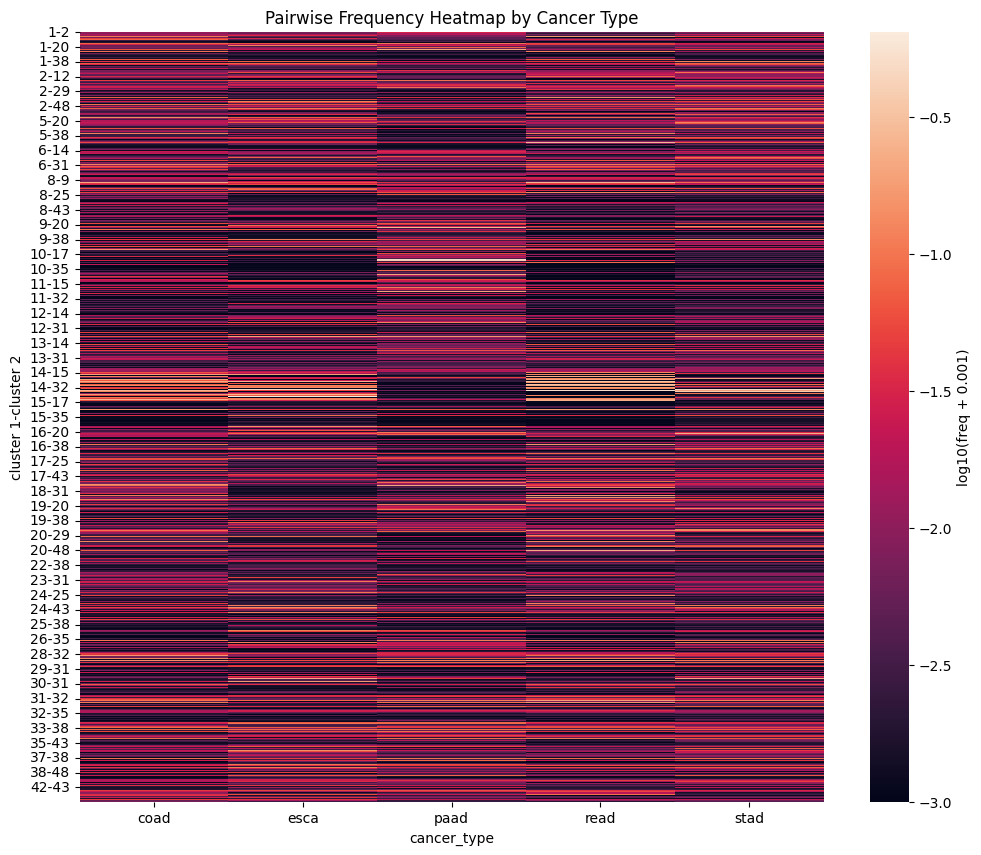

In [39]:
plt.figure(figsize=(12, 10))
sns.heatmap(np.log10(freq_df+ 0.001),cmap='rocket',cbar_kws={'label': 'log10(freq + 0.001)'})
plt.title('Pairwise Frequency Heatmap by Cancer Type')
plt.savefig('png/pairwise_heatmap.png')
plt.show()

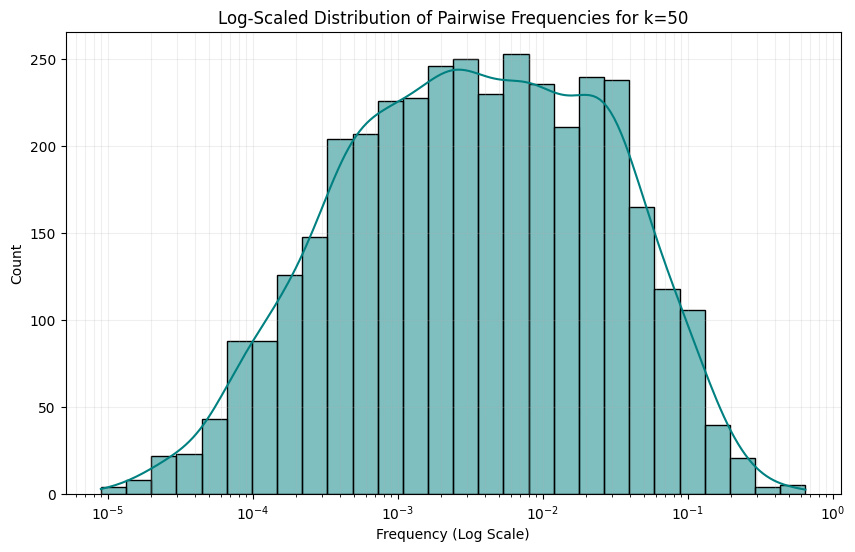

In [52]:
plt.figure(figsize=(10, 6))
# log_scale=True automatically calculates logarithmic bins
sns.histplot(data=filtered_df, x='frequency', log_scale=True, kde=True, color='teal')

plt.title('Log-Scaled Distribution of Pairwise Frequencies for k=50')
plt.xlabel('Frequency (Log Scale)')
plt.ylabel('Count')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.savefig('png/pairwise_freq_dist.png') 
plt.show()

In [50]:
filtered_df 

,cancer_type,cluster 1,cluster 2,contact count,total cluster 1,total_c1_interactions,frequency
49,coad,1,2,3739,43957,351321,0.010643
52,coad,1,5,2228,36195,289237,0.007703
53,coad,1,6,4471,35829,286306,0.015616
55,coad,1,8,1612,19618,156871,0.010276
56,coad,1,9,33960,40767,325839,0.104223
...,...,...,...,...,...,...,...
5807,stad,44,48,3816,63961,505297,0.007552
5808,stad,44,49,39,17637,139913,0.000279
5816,stad,47,48,12384,85161,647334,0.019131
5817,stad,47,49,5744,143759,1106262,0.005192


In [5]:
df.index.set_names(['cancer_type', 'tcga_id', 'number'], inplace=True)
df = df[df.index.get_level_values('cancer_type') != 'luad']
df

label  \
cancer_type tcga_id                                            number         
paad        TCGA-HZ-A9TJ-01Z-00-DX1.CB2953B6-9601-4300-BC89... 0          0   
                                                               1          0   
                                                               2         46   
                                                               3         46   
                                                               4         46   
...                                                                     ...   
read        TCGA-F5-6861-01Z-00-DX1.011B771B-F52E-412E-9352... 36609     13   
                                                               36610     29   
                                                               36611     29   
                                                               36612     13   
                                                               36613     13   

                                                                           X  \
cancer_type tcga_id                                            number          
paad        TCGA-HZ-A9TJ-01Z-00-DX1.CB2953B6-9601-4300-BC89... 0        1792   
                                                               1        1792   
                                                               2        2048   
                                                               3        2048   
                                                               4        2048   
...                                                                      ...   
read        TCGA-F5-6861-01Z-00-DX1.011B771B-F52E-412E-9352... 36609   94208   
                                                               36610   94208   
                                                               36611   94208   
                                                               36612   94208   
                                                               36613   94208   

                                                                           Y  
cancer_type tcga_id                                            number         
paad        TCGA-HZ-A9TJ-01Z-00-DX1.CB2953B6-9601-4300-BC89... 0       11264  
                                                               1       11520  
                                                               2        9984  
                                                               3       10240  
                                                               4       10496  
...                                                                      ...  
read        TCGA-F5-6861-01Z-00-DX1.011B771B-F52E-412E-9352... 36609   20736  
                                                               36610   20992  
                                                               36611   21248  
                                                               36612   21504  
                                                               36613   21760  

[58780353 rows x 3 columns]

In [6]:
label_dist = df.groupby('label').size().reset_index(name='counts')
label_dist 

/tmp/ipykernel_1507613/2463595963.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  label_dist = df.groupby('label').size().reset_index(name='counts')


,label,counts
0,0,1184131
1,1,1006797
2,2,767909
3,3,1589054
4,4,1644894
5,5,923986
6,6,1896491
7,7,718965
8,8,2435551
9,9,1009464


In [7]:
df_summary = df.groupby(level=['cancer_type', 'tcga_id']).agg(
    label_count=('label', 'size'),
).reset_index()

df_summary

,cancer_type,tcga_id,label_count
0,coad,TCGA-3L-AA1B-01Z-00-DX1.8923A151-A690-40B7-9E5...,59070
1,coad,TCGA-3L-AA1B-01Z-00-DX2.17CE3683-F4B1-4978-A28...,31893
2,coad,TCGA-4N-A93T-01Z-00-DX2.875E7F95-A6D4-4BEB-A33...,90902
3,coad,TCGA-4T-AA8H-01Z-00-DX1.A46C759C-74A2-4724-B6B...,100485
4,coad,TCGA-5M-AAT4-01Z-00-DX1.725C46CA-9354-43AC-AA8...,100221
...,...,...,...
1306,stad,TCGA-VQ-AA6I-01Z-00-DX1.B11762F9-1DA7-4140-8F4...,69068
1307,stad,TCGA-VQ-AA6J-01Z-00-DX1.212AF324-26E9-4807-A64...,65341
1308,stad,TCGA-VQ-AA6K-01Z-00-DX1.8AF14797-0C31-4DF3-94A...,3549
1309,stad,TCGA-ZA-A8F6-01Z-00-DX1.89510833-5BC8-4983-817...,28795


In [8]:
label_counts = df.groupby(['tcga_id'])['label'].value_counts().unstack(fill_value=0)
all_labels = list(range(50))
label_counts = label_counts.reindex(columns=all_labels, fill_value=0)

In [9]:
label_counts 

label,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
tcga_id,,,,,,,,,,,,,,,,,,,,,
TCGA-2H-A9GF-01Z-00-DX1.FA1016AF-3FE3-45DC-A77B-F1ACC2B33B2A,51,116,1577,0,0,32,3485,16,1,259,...,662,26309,6627,22,587,0,2806,3975,17179,852
TCGA-2H-A9GG-01Z-00-DX1.0C979026-128C-4124-96CB-0B93FF35CFFF,59,68,9,0,0,1,361,96,1,3099,...,12,1199,2642,8275,133,0,1013,8740,9961,0
TCGA-2H-A9GH-01Z-00-DX1.B2BF80D6-D348-4C5F-A205-6827684BF3B6,48,2,16,1,1,0,30,152,0,3559,...,133,490,37,84,76,1,980,4105,9413,1473
TCGA-2H-A9GI-01Z-00-DX1.02AA1DD3-2082-4B82-B396-957A127D8278,71,58,45,0,0,0,133,4,0,19826,...,489,365,519,6,108,0,1724,366,7354,749
TCGA-2H-A9GJ-01Z-00-DX1.F6CC7FC9-85DB-4791-B367-312F1AA3CDA2,34,0,2,0,0,0,118,15,0,2096,...,274,5,373,4,64,0,2220,8728,28492,244
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-Z6-A9VB-01Z-00-DX1.D35A32ED-DFEE-4070-9542-F91726BDB6A2,0,685,174,0,0,627,177,1,0,2,...,0,229,346,1,915,0,2155,37,4502,7
TCGA-Z6-AAPN-01Z-00-DX1.345F7431-CD48-40DB-89D6-A419E5BA1679,1,1533,75,0,0,337,2036,28,0,0,...,2,14805,636,6,196,1,7343,297,0,62
TCGA-ZA-A8F6-01Z-00-DX1.89510833-5BC8-4983-817E-0E9244824168,1,420,15,0,0,336,5471,464,0,2,...,549,3058,832,1125,3,0,3080,239,0,8192


In [10]:
label_counts.columns

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49],
      dtype='int64', name='label')

In [11]:
label_counts.columns.name = None
label_counts 

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
tcga_id,,,,,,,,,,,,,,,,,,,,,
TCGA-2H-A9GF-01Z-00-DX1.FA1016AF-3FE3-45DC-A77B-F1ACC2B33B2A,51,116,1577,0,0,32,3485,16,1,259,...,662,26309,6627,22,587,0,2806,3975,17179,852
TCGA-2H-A9GG-01Z-00-DX1.0C979026-128C-4124-96CB-0B93FF35CFFF,59,68,9,0,0,1,361,96,1,3099,...,12,1199,2642,8275,133,0,1013,8740,9961,0
TCGA-2H-A9GH-01Z-00-DX1.B2BF80D6-D348-4C5F-A205-6827684BF3B6,48,2,16,1,1,0,30,152,0,3559,...,133,490,37,84,76,1,980,4105,9413,1473
TCGA-2H-A9GI-01Z-00-DX1.02AA1DD3-2082-4B82-B396-957A127D8278,71,58,45,0,0,0,133,4,0,19826,...,489,365,519,6,108,0,1724,366,7354,749
TCGA-2H-A9GJ-01Z-00-DX1.F6CC7FC9-85DB-4791-B367-312F1AA3CDA2,34,0,2,0,0,0,118,15,0,2096,...,274,5,373,4,64,0,2220,8728,28492,244
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-Z6-A9VB-01Z-00-DX1.D35A32ED-DFEE-4070-9542-F91726BDB6A2,0,685,174,0,0,627,177,1,0,2,...,0,229,346,1,915,0,2155,37,4502,7
TCGA-Z6-AAPN-01Z-00-DX1.345F7431-CD48-40DB-89D6-A419E5BA1679,1,1533,75,0,0,337,2036,28,0,0,...,2,14805,636,6,196,1,7343,297,0,62
TCGA-ZA-A8F6-01Z-00-DX1.89510833-5BC8-4983-817E-0E9244824168,1,420,15,0,0,336,5471,464,0,2,...,549,3058,832,1125,3,0,3080,239,0,8192


In [12]:
# 1. Move 'tcga_id' from the index to a regular column
label_counts = label_counts.reset_index()
label_counts 

,tcga_id,0,1,2,3,4,5,6,7,8,...,40,41,42,43,44,45,46,47,48,49
0,TCGA-2H-A9GF-01Z-00-DX1.FA1016AF-3FE3-45DC-A77...,51,116,1577,0,0,32,3485,16,1,...,662,26309,6627,22,587,0,2806,3975,17179,852
1,TCGA-2H-A9GG-01Z-00-DX1.0C979026-128C-4124-96C...,59,68,9,0,0,1,361,96,1,...,12,1199,2642,8275,133,0,1013,8740,9961,0
2,TCGA-2H-A9GH-01Z-00-DX1.B2BF80D6-D348-4C5F-A20...,48,2,16,1,1,0,30,152,0,...,133,490,37,84,76,1,980,4105,9413,1473
3,TCGA-2H-A9GI-01Z-00-DX1.02AA1DD3-2082-4B82-B39...,71,58,45,0,0,0,133,4,0,...,489,365,519,6,108,0,1724,366,7354,749
4,TCGA-2H-A9GJ-01Z-00-DX1.F6CC7FC9-85DB-4791-B36...,34,0,2,0,0,0,118,15,0,...,274,5,373,4,64,0,2220,8728,28492,244
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1306,TCGA-Z6-A9VB-01Z-00-DX1.D35A32ED-DFEE-4070-954...,0,685,174,0,0,627,177,1,0,...,0,229,346,1,915,0,2155,37,4502,7
1307,TCGA-Z6-AAPN-01Z-00-DX1.345F7431-CD48-40DB-89D...,1,1533,75,0,0,337,2036,28,0,...,2,14805,636,6,196,1,7343,297,0,62
1308,TCGA-ZA-A8F6-01Z-00-DX1.89510833-5BC8-4983-817...,1,420,15,0,0,336,5471,464,0,...,549,3058,832,1125,3,0,3080,239,0,8192
1309,TCGA-ZQ-A9CR-01Z-00-DX1.C9AC9991-7054-4068-A7A...,3062,0,0,2,0,0,0,49,25247,...,3728,0,1,291,0,48,12,0,0,292


In [13]:
label_counts['total'] = label_counts.loc[:,0:49].sum(axis=1)
label_counts 

,tcga_id,0,1,2,3,4,5,6,7,8,...,41,42,43,44,45,46,47,48,49,total
0,TCGA-2H-A9GF-01Z-00-DX1.FA1016AF-3FE3-45DC-A77...,51,116,1577,0,0,32,3485,16,1,...,26309,6627,22,587,0,2806,3975,17179,852,111126
1,TCGA-2H-A9GG-01Z-00-DX1.0C979026-128C-4124-96C...,59,68,9,0,0,1,361,96,1,...,1199,2642,8275,133,0,1013,8740,9961,0,70962
2,TCGA-2H-A9GH-01Z-00-DX1.B2BF80D6-D348-4C5F-A20...,48,2,16,1,1,0,30,152,0,...,490,37,84,76,1,980,4105,9413,1473,38161
3,TCGA-2H-A9GI-01Z-00-DX1.02AA1DD3-2082-4B82-B39...,71,58,45,0,0,0,133,4,0,...,365,519,6,108,0,1724,366,7354,749,75217
4,TCGA-2H-A9GJ-01Z-00-DX1.F6CC7FC9-85DB-4791-B36...,34,0,2,0,0,0,118,15,0,...,5,373,4,64,0,2220,8728,28492,244,76903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1306,TCGA-Z6-A9VB-01Z-00-DX1.D35A32ED-DFEE-4070-954...,0,685,174,0,0,627,177,1,0,...,229,346,1,915,0,2155,37,4502,7,23414
1307,TCGA-Z6-AAPN-01Z-00-DX1.345F7431-CD48-40DB-89D...,1,1533,75,0,0,337,2036,28,0,...,14805,636,6,196,1,7343,297,0,62,43715
1308,TCGA-ZA-A8F6-01Z-00-DX1.89510833-5BC8-4983-817...,1,420,15,0,0,336,5471,464,0,...,3058,832,1125,3,0,3080,239,0,8192,28795
1309,TCGA-ZQ-A9CR-01Z-00-DX1.C9AC9991-7054-4068-A7A...,3062,0,0,2,0,0,0,49,25247,...,0,1,291,0,48,12,0,0,292,88838


In [14]:
# 1. Create the dictionary mapping from your first dataframe (let's call it df_source)
# We set tcga_id as index so 'to_dict' uses it as the keys
mapping_dict = df_summary.set_index('tcga_id')['cancer_type'].to_dict()

# 2. Map this dictionary onto the label_counts dataframe
# This looks at the 'tcga_id' column in label_counts and finds the matching value in the dict
label_counts['cancer_type'] = label_counts['tcga_id'].map(mapping_dict)

# 3. Optional: Reorder columns to put cancer_type at the front
cols = ['cancer_type'] + [c for c in label_counts.columns if c != 'cancer_type']
label_counts = label_counts[cols]

label_counts 

,cancer_type,tcga_id,0,1,2,3,4,5,6,7,...,41,42,43,44,45,46,47,48,49,total
0,esca,TCGA-2H-A9GF-01Z-00-DX1.FA1016AF-3FE3-45DC-A77...,51,116,1577,0,0,32,3485,16,...,26309,6627,22,587,0,2806,3975,17179,852,111126
1,esca,TCGA-2H-A9GG-01Z-00-DX1.0C979026-128C-4124-96C...,59,68,9,0,0,1,361,96,...,1199,2642,8275,133,0,1013,8740,9961,0,70962
2,esca,TCGA-2H-A9GH-01Z-00-DX1.B2BF80D6-D348-4C5F-A20...,48,2,16,1,1,0,30,152,...,490,37,84,76,1,980,4105,9413,1473,38161
3,esca,TCGA-2H-A9GI-01Z-00-DX1.02AA1DD3-2082-4B82-B39...,71,58,45,0,0,0,133,4,...,365,519,6,108,0,1724,366,7354,749,75217
4,esca,TCGA-2H-A9GJ-01Z-00-DX1.F6CC7FC9-85DB-4791-B36...,34,0,2,0,0,0,118,15,...,5,373,4,64,0,2220,8728,28492,244,76903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1306,esca,TCGA-Z6-A9VB-01Z-00-DX1.D35A32ED-DFEE-4070-954...,0,685,174,0,0,627,177,1,...,229,346,1,915,0,2155,37,4502,7,23414
1307,esca,TCGA-Z6-AAPN-01Z-00-DX1.345F7431-CD48-40DB-89D...,1,1533,75,0,0,337,2036,28,...,14805,636,6,196,1,7343,297,0,62,43715
1308,stad,TCGA-ZA-A8F6-01Z-00-DX1.89510833-5BC8-4983-817...,1,420,15,0,0,336,5471,464,...,3058,832,1125,3,0,3080,239,0,8192,28795
1309,stad,TCGA-ZQ-A9CR-01Z-00-DX1.C9AC9991-7054-4068-A7A...,3062,0,0,2,0,0,0,49,...,0,1,291,0,48,12,0,0,292,88838


In [15]:
label_counts['total'].sum() 

np.int64(58780353)

In [17]:

# 1. Melt the dataframe from wide to long format
# This turns columns 0-49 into a single 'cluster_label' column
df_long = label_counts.melt(
    id_vars=['cancer_type'], 
    value_vars=[i for i in range(50)], # Columns 0 through 49
    var_name='cluster_label', 
    value_name='count'
)

# 2. Group by cancer_type and cluster_label to get the total counts
# This aggregates the counts across all TCGA IDs for each cancer type
final_df = df_long.groupby(['cancer_type', 'cluster_label'])['count'].sum().reset_index()

# 3. Rename column for clarity
final_df.columns = ['cancer_type', 'cluster_label', 'total_counts_label']

final_df 

,cancer_type,cluster_label,total_counts_label
0,coad,0,688333
1,coad,1,46686
2,coad,2,200743
3,coad,3,996231
4,coad,4,1034721
...,...,...,...
245,stad,45,583181
246,stad,46,584456
247,stad,47,192047
248,stad,48,351648


In [20]:
# 1. Calculate the denominator for each cancer type
# This sums up all 'total_counts_label' for each group (coad, stad, etc.)
# and maps that total back to every row in that group.
final_df['total'] = final_df.groupby('cancer_type')['total_counts_label'].transform('sum')

# 2. Calculate the frequency
# Now each cancer type is divided by its own specific total count
final_df['frequency'] = final_df['total_counts_label'] / final_df['total']

# 3. Optional: Drop the denominator column if you don't need it in the final output
final_df = final_df.drop(columns=['total'])

final_df

,cancer_type,cluster_label,total_counts_label,frequency
0,coad,0,688333,0.045096
1,coad,1,46686,0.003059
2,coad,2,200743,0.013152
3,coad,3,996231,0.065268
4,coad,4,1034721,0.067789
...,...,...,...,...
245,stad,45,583181,0.029641
246,stad,46,584456,0.029706
247,stad,47,192047,0.009761
248,stad,48,351648,0.017873


In [22]:
# 1. Define the noisy clusters
noisy = [0, 3, 4, 7, 21, 27, 34, 39, 45, 46]

# 2. Filter out noisy clusters from BOTH cluster columns
# This ensures we only look at high-quality biological interactions
clean_df = final_df[
    (~final_df['cluster_label'].isin(noisy))
].copy()
clean_df 

,cancer_type,cluster_label,total_counts_label,frequency
1,coad,1,46686,0.003059
2,coad,2,200743,0.013152
5,coad,5,28568,0.001872
6,coad,6,316754,0.020752
8,coad,8,103043,0.006751
...,...,...,...,...
243,stad,43,737310,0.037475
244,stad,44,245726,0.012489
247,stad,47,192047,0.009761
248,stad,48,351648,0.017873


In [23]:
frequency_df = clean_df.set_index(['cluster_label','cancer_type'])['frequency'].unstack().fillna(0)
frequency_df 

cancer_type,coad,esca,paad,read,stad
cluster_label,,,,,
1,0.003059,0.038683,0.020564,0.003649,0.021188
2,0.013152,0.004684,0.028258,0.007441,0.008527
5,0.001872,0.002561,0.072240,0.001745,0.001368
6,0.020752,0.045133,0.066806,0.014321,0.020285
8,0.006751,0.042974,0.015606,0.011381,0.090377
9,0.023535,0.006041,0.001275,0.034550,0.021599
10,0.004844,0.074302,0.000152,0.002341,0.014643
11,0.018354,0.014653,0.003144,0.030371,0.031557
12,0.055114,0.006447,0.005466,0.036070,0.011382


In [63]:
frequency_df.mean(axis=0) 

cancer_type
coad    0.017590
esca    0.020754
paad    0.022646
read    0.016802
stad    0.021678
dtype: float64

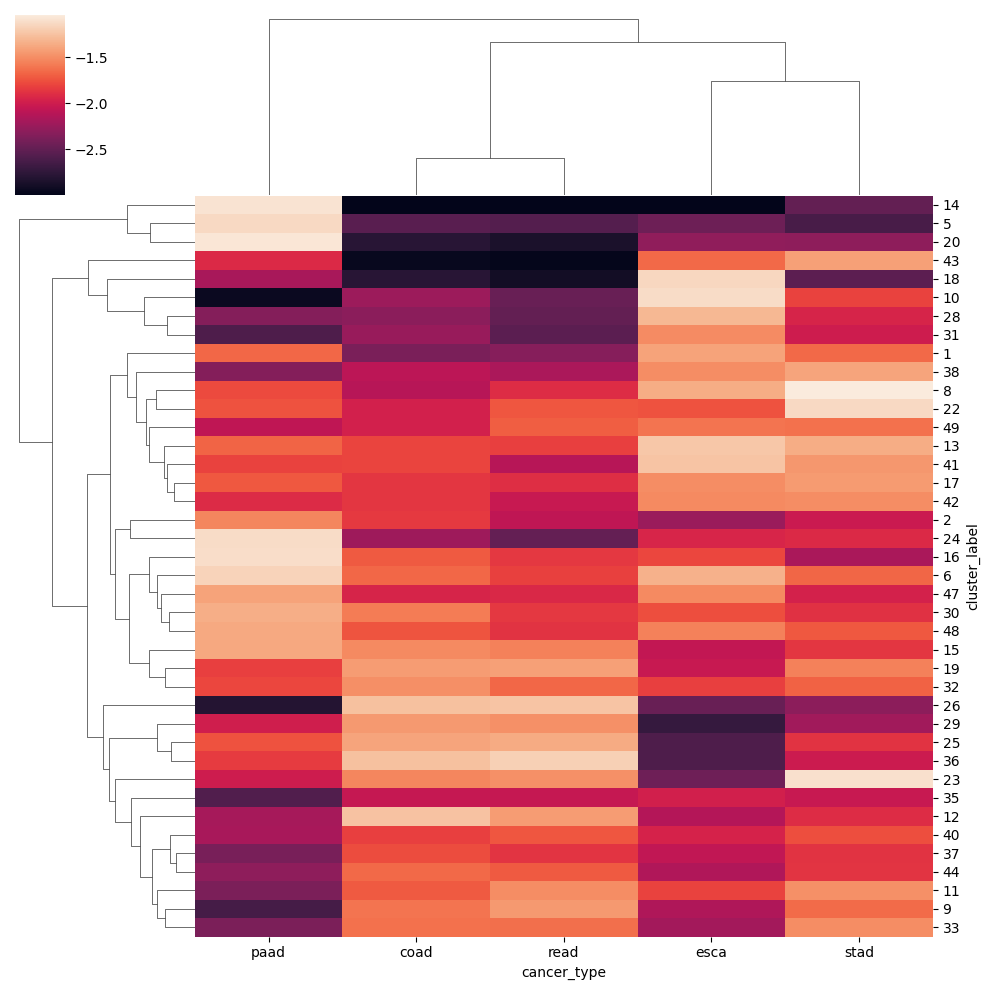

In [61]:
sns.clustermap(np.log10(frequency_df+ 0.001), yticklabels=True)
plt.savefig('png/cluster_hierarchical_clustermap.png') 

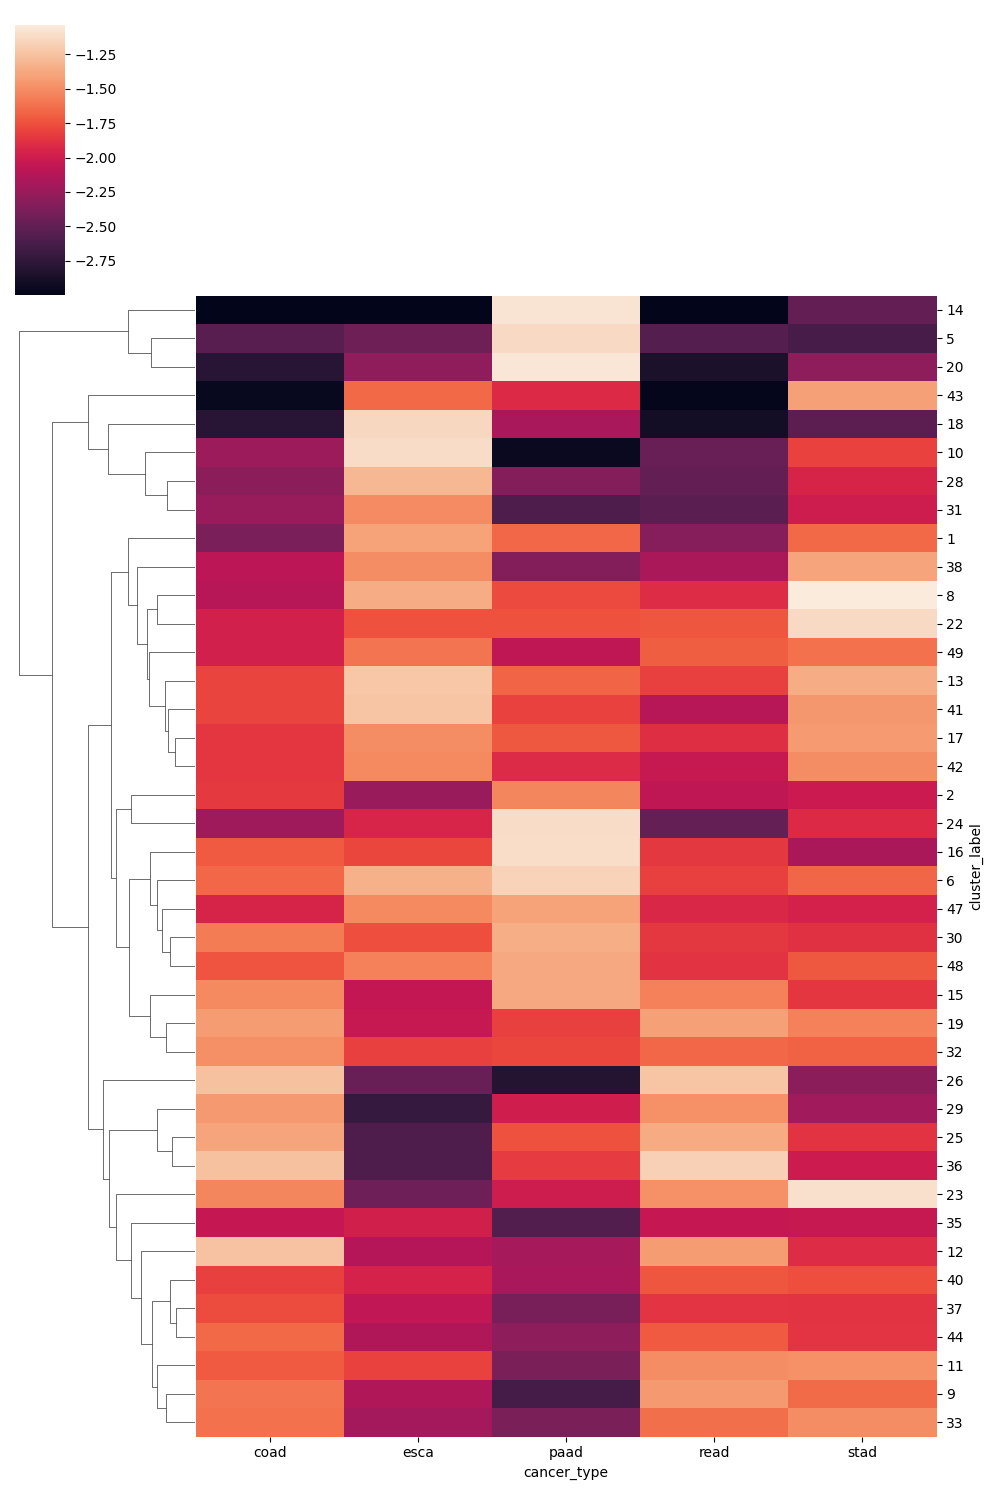

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare your pivot table (assuming df is your 250x4 dataframe)
pivot_df = clean_df.pivot(index='cluster_label', columns='cancer_type', values='frequency')

# 2. Reorder columns manually
desired_order = ['coad', 'esca', 'paad', 'read', 'stad']
pivot_df = pivot_df[desired_order]

# 3. Create the Clustermap
g = sns.clustermap(
    np.log10(pivot_df+0.001),
    col_cluster=False,      # Prevents Seaborn from reordering your cancer types
    row_cluster=True,       # Keeps the clustering for cluster_labels
    yticklabels=True,       # Forces all 50 row labels to show
    cmap='rocket',          # Matches your current aesthetic
    figsize=(10, 15)        # Increased height helps labels breathe
)

# 4. Cleanup label rotation if needed
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)
plt.savefig('png/cluster_hierarchical_clustermap.png') 
plt.show()